<a href="https://colab.research.google.com/github/paldee/Data-Science-PM2.5/blob/main/CRISP_DM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Business Understanding


## ที่มาความสำคัญ


ปัญหามลพิษทางอากาศ โดยเฉพาะ PM2.5เป็นปัญหาที่ส่งผลกระทบต่อสุขภาพอย่างรุนแรง การมีระบบที่สามารถคาดการณ์แนวโน้มล่วงหน้าได้จะช่วยให้เกิดการวางแผนรับมือและการป้องกันที่มีประสิทธิภาพ

## เป้าหมายหลักของ business understanding

เพื่อสร้างระบบพยากรณ์ปริมาณฝุ่น PM2.5 ล่วงหน้า1วัน เพื่อใช้เป็นข้อมูลประกอบการตัดสินใจในการแจ้งเตือนให้เตรียมตัวป้องกันสุขภาพ หรือช่วยให้ผู้วางนโยบายมีเวลาเตรียมการจัดการปัญหาล่วงหน้า โดยใช้ข้อมูลจาก 7 วันข้างหลังเพื่อดูเเนวโน้ว

## เป้าหมายด้านการวิเคราะห์ข้อมูล


สร้าง model Machine Learning ประเภท regression เพื่อทำนายค่าฝุ่น PM2.5


## เกณฑ์การวัดประสิทธิภาพ


โมเดลมีค่าความคลาดเคลื่อน (เช่น ค่า RMSE หรือ MAE) ต่ำในระดับที่ยอมรับได้เมื่อประเมินกับชุดข้อมูลทดสอบ (Test Set)

# Data Understanding

## นำเข้าเเละจัดรูปเเบบข้อมูล


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional libraries for visualization (recommended)
import seaborn as sns
import plotly.express as px

In [ ]:
from google.colab import files
uploaded = files.upload()
uploaded.keys()

Saving pm2.52024.csv to pm2.52024 (1).csv
Saving pm2.52023.csv to pm2.52023 (1).csv
Saving pm2.52022.csv to pm2.52022 (1).csv
Saving pm2.52021.csv to pm2.52021 (1).csv


dict_keys(['pm2.52024 (1).csv', 'pm2.52023 (1).csv', 'pm2.52022 (1).csv', 'pm2.52021 (1).csv'])

In [ ]:
df_2021 = pd.read_csv("pm2.52021.csv")
df_2022 = pd.read_csv("pm2.52022.csv")
df_2023 = pd.read_csv("pm2.52023.csv")
df_2024 = pd.read_csv("pm2.52024.csv")

for df in [df_2021, df_2022, df_2023]:
    df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y")
df_2024["Date"] = pd.to_datetime(df_2024["Date"], format="%d/%m/%Y")

df_all = pd.concat([df_2021, df_2022, df_2023, df_2024], axis=0, ignore_index=True)
df_all = df_all.sort_values("Date").reset_index(drop=True)

df_all

,Date,02T,05T,10T,11T,12T,59T,61T,03T,50T,...,72T,104T,106T,107T,108T,109T,110T,111T,112T,105T
0,2021-01-01,27.0,20.0,22.0,25.0,22.0,20.0,25.0,24.0,25.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-01-02,32.0,25.0,26.0,27.0,27.0,23.0,26.0,29.0,31.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-01-03,46.0,37.0,33.0,41.0,40.0,38.0,29.0,44.0,44.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-01-04,39.0,31.0,32.0,36.0,38.0,36.0,28.0,46.0,41.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021-01-05,50.0,31.0,31.0,32.0,44.0,28.0,24.0,67.0,41.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1272,2024-12-27,47.4,35.4,35.8,35.4,35.9,23.2,34.6,43.9,41.6,...,30.1,30.3,10.7,23.5,20.7,22.9,16.9,12.4,10.1,36.9
1273,2024-12-28,28.2,22.9,22.5,22.8,23.4,17.0,22.6,25.6,28.2,...,18.2,24.4,10.1,20.4,19.3,22.7,17.4,9.7,9.8,14.4
1274,2024-12-29,25.8,20.1,20.4,20.6,20.7,17.0,20.1,22.3,23.8,...,18.7,25.1,15.1,32.9,17.9,35.3,29.5,23.2,22.5,12.0
1275,2024-12-30,40.0,28.4,28.2,28.4,28.1,26.2,27.1,34.3,33.2,...,32.6,38.6,24.9,32.2,27.1,38.9,31.8,25.2,30.2,19.6


In [ ]:
# 1. แปลง Column 'Date' ให้เป็น datetime object
df_all['Date'] = pd.to_datetime(df_all['Date'])
# 2. ตั้งค่า Date ให้เป็น Index
df = df_all.set_index('Date')

##EDA Missing Value เพื่อศึกษาพฤติกรรมค่าว่าง

Heatmap เพื่อดูการกระจายตัวของค่าว่าง

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from current font.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from current font.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from current font.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from current font.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from current font.
  fig.canvas.pr

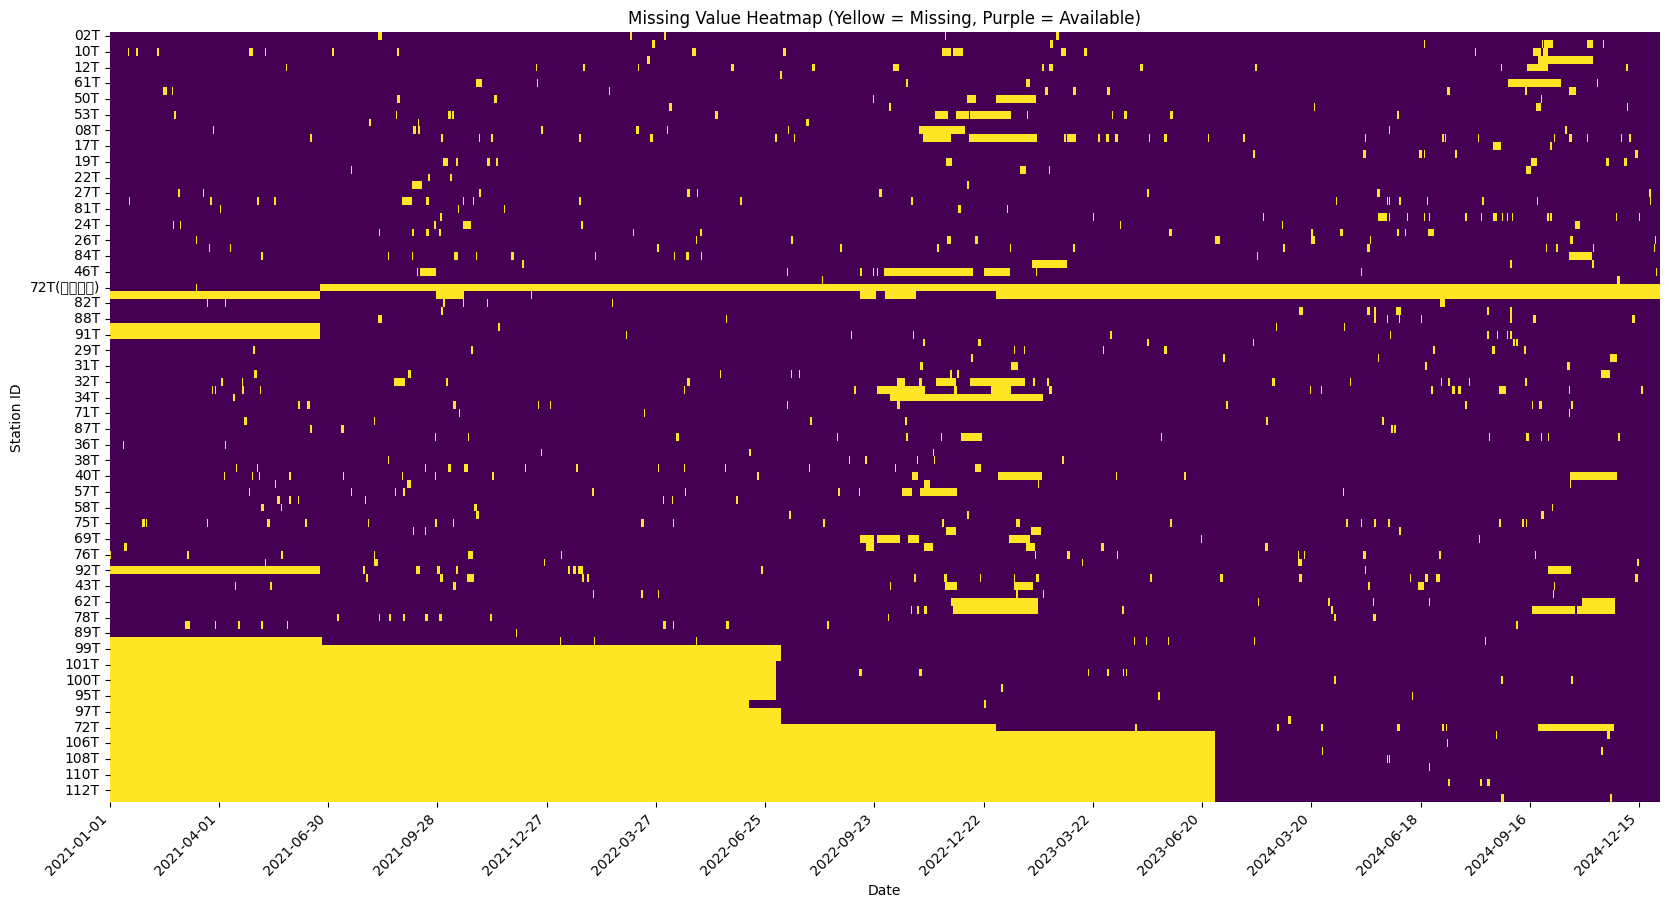

In [ ]:
plt.figure(figsize=(20, 10))
ax = sns.heatmap(df.isnull().T, cbar=False, cmap='viridis')
n_days = len(df)
xticks_interval = 90
xticks_locs = range(0, n_days, xticks_interval)
xtick_labels = [df.index[i].strftime('%Y-%m-%d') for i in xticks_locs if i < n_days]
plt.xticks(ticks=xticks_locs, labels=xtick_labels, rotation=45, ha='right')

plt.title('Missing Value Heatmap (Yellow = Missing, Purple = Available)')
plt.xlabel('Date')
plt.ylabel('Station ID')
plt.show()

จากกราฟ
สีเหลืองหมายถึง missing value ม่วงหมายถึง มีการบันทึกค่า

ตั้งข้อสันนิษฐานดังนี้
1. สถานีติดตั้งทีหลัง
   จุดสังเกต: โซนด้านล่างสุดของกราฟ ตั้งแต่ Station 99T ลงไปจนถึง 112T เเละสถานี 90T, 91T, 92T, 72T(ใหม่)
   สิ่งที่เห็น: แถบสีเหลืองขนาดใหญ่ทางซ้าย ซึ่งหมายถึงช่วงเวลาติดตั้ง Sensor ข้อมูลไม่ได้หายเพราะ Error แต่หายเพราะตอนนั้น Sensor ยังไม่ได้ถูกติดตั้ง เป็น missing เเบบ MAR
   วิธีจัดการ: ห้ามเติมค่า (No Imputation): ห้ามใส่ 0 หรือค่าเฉลี่ยเด็ดขาด
   Filter Date: ให้ตัดข้อมูลช่วงสีเหลืองทิ้ง โดยกำหนด Start Date ของแต่ละ Station ให้ตรงกับวันที่ข้อมูลเริ่มเข้ามาวันแรก
2. สถานีที่ไม่ถูกใช้งาน
   จุดสังเกต: Station 72T(เก่า): เป็นแถบสีเหลืองยาวเกือบ 100% มีสีม่วงโผล่มานิดเดียวตอนต้น
   วิธีจัดการ: Drop Column ทิ้ง เก็บไว้จะเป็น Noise ให้กับโมเดล เพราะข้อมูลหายเกิน 80-90%
3. ระบบล่ม
   จุดสังเกต: ช่วงปลายปี 2022 ถึงต้นปี 2023 (ช่วง 2022-09-23 ถึง 2023-03-22)
   สิ่งที่เห็น: มีกลุ่มก้อนสีเหลืองเกิดขึ้นพร้อมกันในหลาย Station โดยเฉพาะกลุ่มกลางๆ เช่น 46T, 33T, 60T, 53T, 50T
   ความหมาย: น่าจะเป็นเพราะเหตุการณ์ภายนอก เช่น Gateway/Router ของโซนนั้นเสีย ไฟดับในพื้นที่นั้น
   วิธีจัดการ: หากคุณต้องวิเคราะห์ความสัมพันธ์ระหว่าง Station ข้อมูลช่วงนี้อาจจะใช้ไม่ได้ (Unreliable) ควรพิจารณาตัดช่วงเวลานี้ออก หรือ Mark ไว้ว่าเป็น Event พิเศษ

# Data Preparation


## จัดการ Missing Values


### 1 การจัดการข้อมูลของสถานีที่ไม่ถูกใช้งานเเล้ว(มีค่าว่างมากกว่า80%)

In [ ]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 6)

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3651 (\N{THAI CHARACTER SARA AI MAIMUAN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12

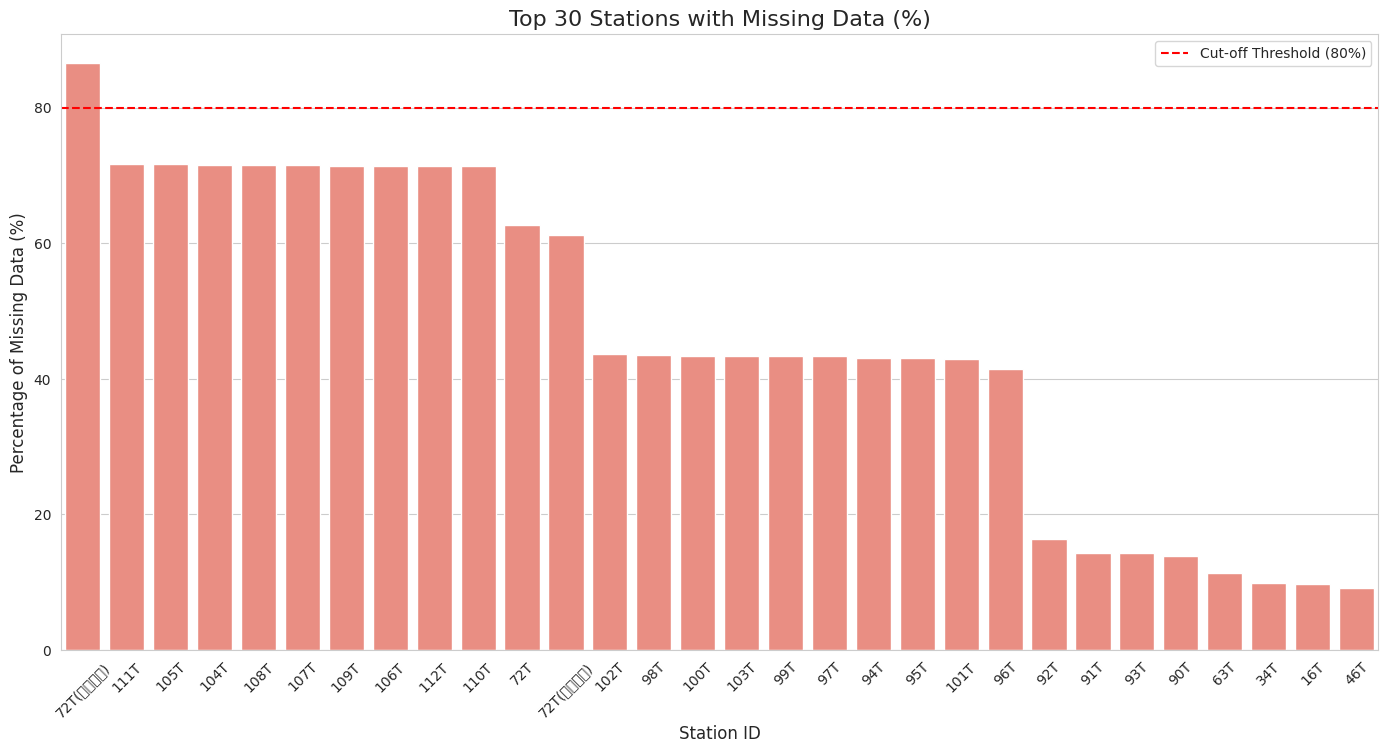

In [ ]:
# คำนวณ % ข้อมูลที่หายไปของแต่ละ Station
missing_percentage = df.isnull().mean() * 100

missing_sorted = missing_percentage[missing_percentage > 0].sort_values(ascending=False)

# เลือกมาแสดงแค่ 30 อันดับแรก
top_missing = missing_sorted.head(30)

plt.figure(figsize=(17, 8))
ax = sns.barplot(x=top_missing.index, y=top_missing.values, color='salmon')

# ขีดเส้นแดงที่ 80% เพื่อบอกที่เราจะตัดทิ้ง
plt.axhline(y=80, color='red', linestyle='--', label='Cut-off Threshold (80%)')

plt.title('Top 30 Stations with Missing Data (%)', fontsize=16)
plt.ylabel('Percentage of Missing Data (%)', fontsize=12)
plt.xlabel('Station ID', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.show()

กราฟเพื่อประกอบการตัดสินใจว่าสามารถตัดสถานีไหนทิ้งได้บ้าง จากกราฟข้อมูลที่หายเกิน 80 จะทำให้เป็นขยะในโมเดลควรตัดทิ้งเลย ซึ่งคือสถานี 72T(เก่า) คาดว่าไม่น่าจะใช้เเล้ว(ใช้เเค่ช่วงต้นหลังจากนั้นมาใช้ 72T(ใหม่))

 สร้าง station_quality_report เพื่อศึกษารายละเอียดเพิ่มเติมของการเกิดค่า missing

In [ ]:
# --- 1. ฟังก์ชันคำนวณ Internal Gap (หัวใจสำคัญ) ---
def get_longest_internal_gap(series):
    # หาจุดเริ่มต้น (First Valid) และจุดสิ้นสุด (Last Valid) ของข้อมูลจริง
    first_valid = series.first_valid_index()
    last_valid = series.last_valid_index()

    # กรณีสถานีนี้ไม่มีข้อมูลเลย (NaN ล้วน)
    if first_valid is None:
        return 0

    # ตัดข้อมูล: เอาเฉพาะช่วงเวลาตั้งแต่เริ่มมีข้อมูลจนถึงข้อมูลสุดท้าย
    # (นี่คือขั้นตอนตัด Leading/Trailing NaN ตาม Hint ในโจทย์)
    trimmed_series = series.loc[first_valid:last_valid]

    # สร้าง Mask: True ถ้าเป็น NaN, False ถ้ามีข้อมูล
    is_nan = trimmed_series.isna()

    # จัดกลุ่ม NaN ที่ติดกัน (Logic: ค่า cumsum จะเปลี่ยนเมื่อสถานะ NaN/Not-NaN สลับกัน)
    gap_groups = (is_nan != is_nan.shift()).cumsum()

    # นับจำนวน NaN ในแต่ละกลุ่ม
    gap_lengths = trimmed_series.groupby(gap_groups).apply(
        lambda x: len(x) if x.isna().all() else 0
    )

    # คืนค่า gap ที่ยาวที่สุด (หน่วยเป็นชั่วโมง เพราะข้อมูลเราเป็นรายชั่วโมง)
    return gap_lengths.max() if not gap_lengths.empty else 0

# --- 2. ฟังก์ชันสร้าง Report ---
def create_station_quality_report(df):
    report_data = []

    print("กำลังประมวลผล...", end=" ")
    for station in df.columns:
        series = df[station]

        # คำนวณค่าพื้นฐาน
        total_rows = len(series)
        total_missing_hours = series.isna().sum()

        # แปลงชั่วโมงเป็นวัน (หาร 24)
        total_missing_days = total_missing_hours / 24.0

        # เปอร์เซ็นต์ที่หาย
        missing_ratio = (total_missing_hours / total_rows) * 100

        # วันแรกและวันสุดท้ายที่มีข้อมูล
        first_valid = series.first_valid_index()
        last_valid = series.last_valid_index()

        # เรียกฟังก์ชันหา Gap (พระเอกของเรา)
        longest_run = get_longest_internal_gap(series)

        report_data.append({
            'station': station,
            'total missing days': round(total_missing_days, 2),
            'missing ratio (%)': round(missing_ratio, 2),
            'first valid date': first_valid,
            'last valid date': last_valid,
            'longest missing run (hours)': longest_run
        })

    print("เสร็จเรียบร้อย!")
    return pd.DataFrame(report_data)

# --- 3. เรียกใช้งาน ---
# สร้าง Report
quality_report = create_station_quality_report(df)

quality_report.to_csv('station_quality_report.csv', index=False)

# แสดงผลลัพธ์ 10 แถวแรกให้ดู
print(f"บันทึกไฟล์ 'station_quality_report.csv' แล้ว")
quality_report.sample(10)

กำลังประมวลผล... เสร็จเรียบร้อย!
บันทึกไฟล์ 'station_quality_report.csv' แล้ว


,station,total missing days,missing ratio (%),first valid date,last valid date,longest missing run (hours)
69,42T,1.58,2.98,2021-01-01,2024-12-31,6
70,43T,1.62,3.05,2021-01-01,2024-12-31,16
26,26T,0.88,1.64,2021-01-01,2024-12-31,4
42,31T,0.42,0.78,2021-01-01,2024-12-31,5
56,40T,3.92,7.36,2021-01-01,2024-12-31,39
22,81T,0.25,0.47,2021-01-01,2024-12-31,2
5,59T,0.08,0.16,2021-01-01,2024-12-31,2
10,53T,3.00,5.64,2021-01-01,2024-12-31,34
82,100T,23.08,43.38,2022-07-04,2024-12-31,2
88,72T,33.33,62.65,2023-01-01,2024-12-31,62


### 2 การจัดการกับสถานีที่มีช่วงค่าว่างหายติดต่อกันนานเกิน 48 ชั่วโมงเพราะถ้าข้อมูลหายไปไม่นานมากเราลากเส้นเชื่อม(Interpolate) แต่ถ้าหายเป็นสัปดาห์ การลากเส้นเชื่อมจะเหมือนการเดาสุ่มดังนั้นพิจราณาตัดทิ้ง

กราฟเเสดงช่วงเวลาที่ค่าว่างหายไปติดต่อกัน


/tmp/ipykernel_6341/343036126.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3651 (\N{THAI CHARACTER SARA AI MAIMUAN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3627 (\N{THAI CHARACTER HO HIP}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from current font.
  fig.canvas.print_figure(by

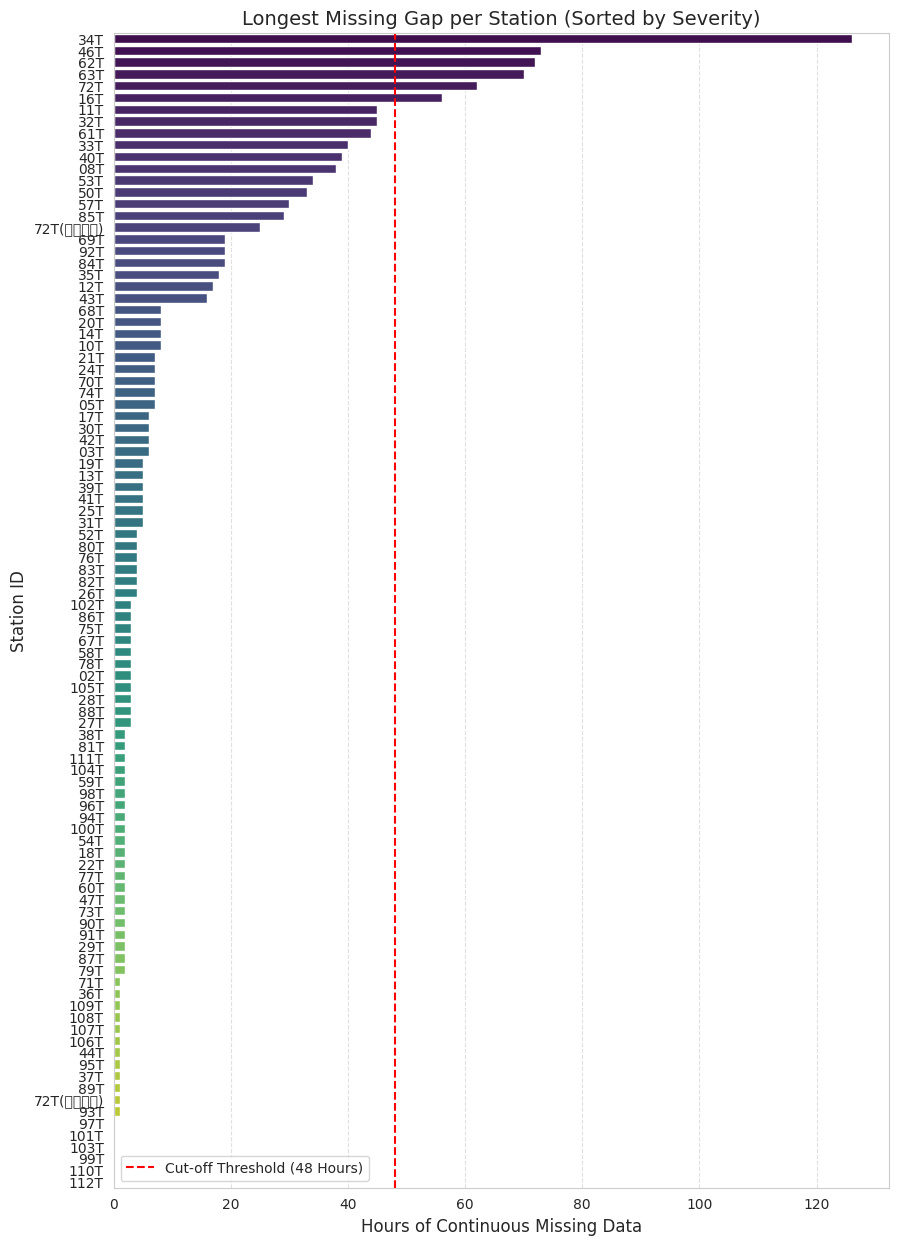

In [ ]:
df_plot = quality_report.sort_values('longest missing run (hours)', ascending=False)
plt.figure(figsize=(10, 15))
sns.barplot(
    data=df_plot,
    x='longest missing run (hours)',
    y='station',
    palette='viridis'
)
limit_hours = 48
plt.axvline(x=limit_hours, color='red', linestyle='--', label=f'Cut-off Threshold ({limit_hours} Hours)')

plt.title('Longest Missing Gap per Station (Sorted by Severity)', fontsize=14)
plt.xlabel('Hours of Continuous Missing Data', fontsize=12)
plt.ylabel('Station ID', fontsize=12)
plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.show()

จัดการข้อมูลที่หายไปนานเกิน 48 ชั่วโมงเเละมีสัดส่วนของค่า missing เกิด 80% (ไม่รวมสถานีที่ติดตั้งทีหลัง)


In [ ]:
# กำหนดเกณฑ์วันที่ติดตั้งเริ่มต้น (อ้างอิงจากข้อมูลส่วนใหญ่คือ 2021-01-01)
base_start_date = '2021-01-01'

# Missing นานเกิน 48 ชั่วโมง
condition_missing_run = quality_report['longest missing run (hours)'] > 48

# สัดส่วน Missing เกิน 20%
condition_missing_ratio = quality_report['missing ratio (%)'] > 20

# เฉพาะสถานีที่ติดตั้งมาตั้งแต่แรก (ไม่เอาสถานีใหม่)
condition_old_station = quality_report['first valid date'] == base_start_date

# 2. รวมเงื่อนไข: (หายเกิน 48 ชม. OR missing > 20%) AND ต้องเป็นสถานีเก่า
to_drop = quality_report[
    (condition_missing_run | condition_missing_ratio) & condition_old_station
]

# 3. ดึงรายชื่อสถานีที่จะลบออกมาเป็น List
stations_to_exclude = to_drop['station'].tolist()
print(f"จำนวนสถานีที่ถูกคัดออก: {len(stations_to_exclude)} สถานี")
print(f"รายชื่อสถานีที่ถูกคัดออก: {stations_to_exclude}")

จำนวนสถานีที่ถูกคัดออก: 6 สถานี
รายชื่อสถานีที่ถูกคัดออก: ['16T', '46T', '72T(เก่า)', '34T', '62T', '63T']


In [ ]:
# 1. ระบุรายชื่อสถานีทั้งหมดที่มีอยู่ใน DataFrame
all_stations = [col for col in df_all.columns if col != 'Date']

# 2. คัดเลือกเฉพาะสถานีที่ "ไม่อยู่" ในรายชื่อสถานีที่ต้องถูกคัดออก (stations_to_exclude)
passed_stations = [s for s in all_stations if s not in stations_to_exclude]

# 3. สร้าง DataFrame ใหม่โดยการ Copy และเลือกเฉพาะคอลัมน์ Date กับสถานีที่ผ่านเกณฑ์
df_cleaned = df_all[['Date'] + passed_stations].copy()

In [ ]:
df_cleaned

,Date,02T,05T,10T,11T,12T,59T,61T,03T,50T,...,72T,104T,106T,107T,108T,109T,110T,111T,112T,105T
0,2021-01-01,27.0,20.0,22.0,25.0,22.0,20.0,25.0,24.0,25.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-01-02,32.0,25.0,26.0,27.0,27.0,23.0,26.0,29.0,31.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-01-03,46.0,37.0,33.0,41.0,40.0,38.0,29.0,44.0,44.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-01-04,39.0,31.0,32.0,36.0,38.0,36.0,28.0,46.0,41.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021-01-05,50.0,31.0,31.0,32.0,44.0,28.0,24.0,67.0,41.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1272,2024-12-27,47.4,35.4,35.8,35.4,35.9,23.2,34.6,43.9,41.6,...,30.1,30.3,10.7,23.5,20.7,22.9,16.9,12.4,10.1,36.9
1273,2024-12-28,28.2,22.9,22.5,22.8,23.4,17.0,22.6,25.6,28.2,...,18.2,24.4,10.1,20.4,19.3,22.7,17.4,9.7,9.8,14.4
1274,2024-12-29,25.8,20.1,20.4,20.6,20.7,17.0,20.1,22.3,23.8,...,18.7,25.1,15.1,32.9,17.9,35.3,29.5,23.2,22.5,12.0
1275,2024-12-30,40.0,28.4,28.2,28.4,28.1,26.2,27.1,34.3,33.2,...,32.6,38.6,24.9,32.2,27.1,38.9,31.8,25.2,30.2,19.6


In [ ]:
df_cleaned['Date'] = pd.to_datetime(df_cleaned['Date'])

# ตั้งคอลัมน์ Date ให้เป็น Index เพื่อให้ heatmap ใช้ข้อมูลนี้ได้โดยตรง
df_cleaned.set_index('Date', inplace=True)

ตรวจสอบค่า missing value ณ ปัจจุบัน

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3651 (\N{THAI CHARACTER SARA AI MAIMUAN}) missing from current font.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3627 (\N{THAI CHARACTER HO HIP}) missing from current font.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from current font.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from current font.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3651 (\N{THAI CHARACTER SARA AI MAIMUAN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3627 (\N{THAI CHARACTER HO HIP}) missing from current font.

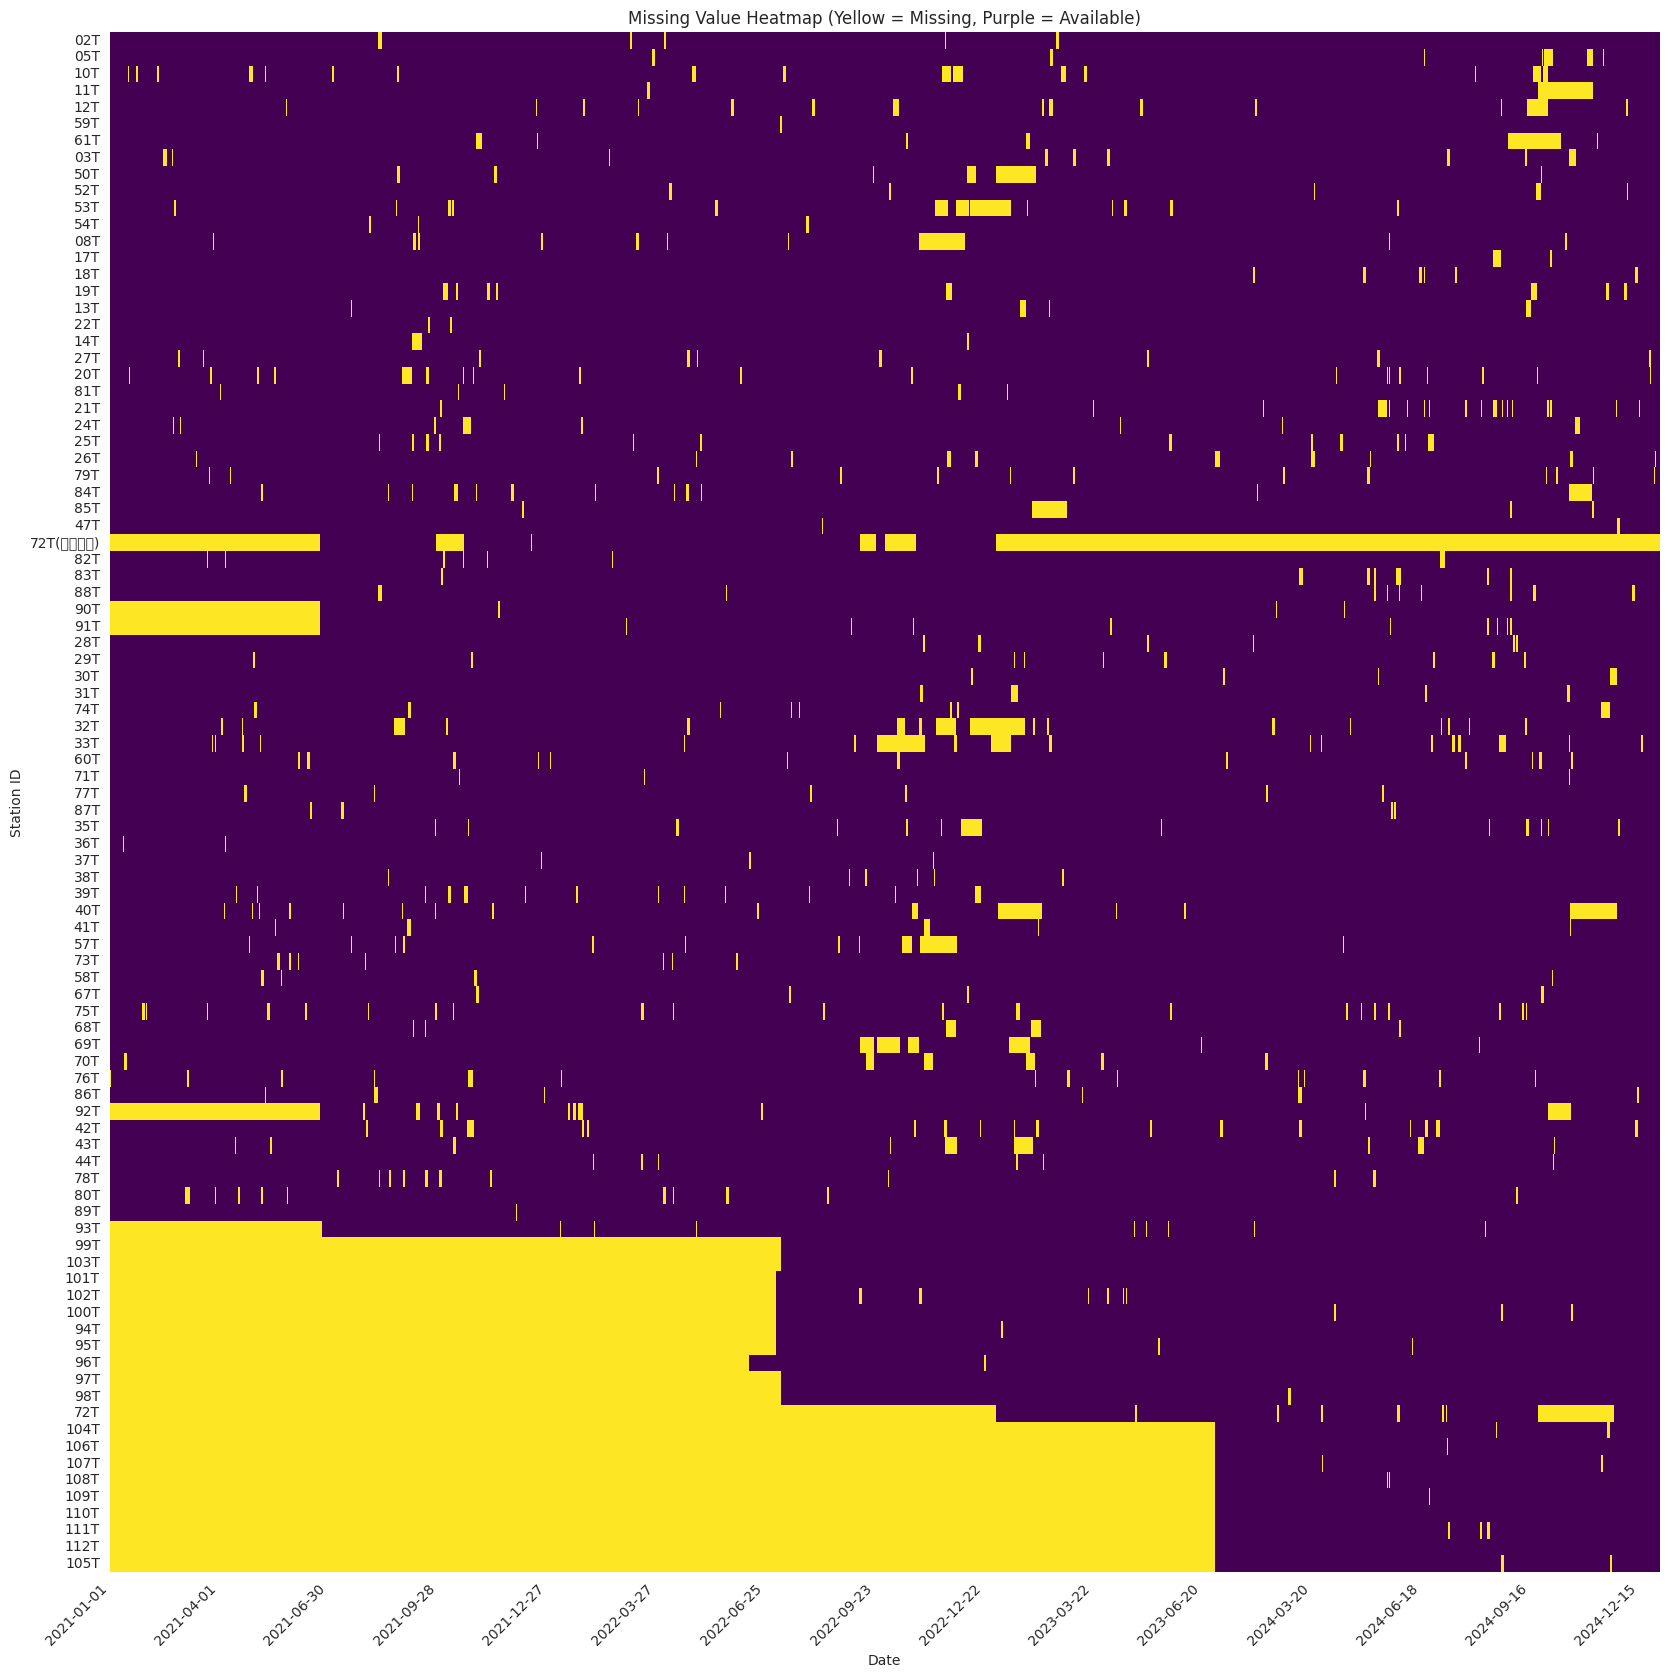

In [ ]:
plt.figure(figsize=(20, 20))
ax = sns.heatmap(df_cleaned.isnull().T, cbar=False, cmap='viridis')
n_days = len(df_cleaned)
xticks_interval = 90
xticks_locs = range(0, n_days, xticks_interval)
xtick_labels = [df_cleaned.index[i].strftime('%Y-%m-%d') for i in xticks_locs if i < n_days]
plt.xticks(ticks=xticks_locs, labels=xtick_labels, rotation=45, ha='right')

plt.title('Missing Value Heatmap (Yellow = Missing, Purple = Available)')
plt.xlabel('Date')
plt.ylabel('Station ID')
plt.show()

### 3 พิจารณาเรื่องกลุ่มของสถานี

เนื่องจากมีสถานีที่พึ่งมาติดตั้งเยอะมาก
ความเห็นของทีม คือสถานีที่ติดตั้งใหม่มีเป็นข้อมูลที่มีประโยชน์เเต่อาจไม่สามารถเอาไปคิดรวมกับสถานีที่ติดตั้งไปก่อนหน้านี้ได้ ดังนั้นเราจะเเบ่งกลุ่มข้อมูลออกเป็นสองชุดคือ ชุดที่มีการติดตั้งมานานเเละชุดของข้อมูลที่พึ่งมาติดตั้งภายหลัง

In [ ]:
all_stations = [col for col in df_cleaned.columns if col.lower() != 'date']
threshold_date = pd.to_datetime('2021-06-30')
station_groups = {
    'legacy_stations': [],
    'new_stations': []
}
for station in all_stations:
    first_valid_idx = df_cleaned[station].first_valid_index()
    if first_valid_idx is not None:
        if isinstance(df_cleaned.index, pd.DatetimeIndex):
            first_date = df_cleaned.index[df_cleaned.index.get_loc(first_valid_idx)]
        elif 'Date' in df_cleaned.columns:
            first_date = pd.to_datetime(df_cleaned.loc[first_valid_idx, 'Date'])
        else:
            first_date = pd.to_datetime(first_valid_idx)

        if first_date <= threshold_date:
            station_groups['legacy_stations'].append(station)
        else:
            station_groups['new_stations'].append(station)

In [ ]:
df_legacy = df_cleaned[station_groups['legacy_stations']].copy()
df_new = df_cleaned[station_groups['new_stations']].copy()

#### 3.1 สถานีที่มีการติดตั้งมานาน

In [ ]:
df_legacy

,02T,05T,10T,11T,12T,59T,61T,03T,50T,52T,...,76T,86T,92T,42T,43T,44T,78T,80T,89T,93T
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-01,27.0,20.0,22.0,25.0,22.0,20.0,25.0,24.0,25.0,26.0,...,NaN,38.0,NaN,19.0,23.0,20.0,7.0,18.0,17.0,NaN
2021-01-02,32.0,25.0,26.0,27.0,27.0,23.0,26.0,29.0,31.0,32.0,...,25.0,44.0,NaN,19.0,24.0,16.0,8.0,13.0,17.0,NaN
2021-01-03,46.0,37.0,33.0,41.0,40.0,38.0,29.0,44.0,44.0,44.0,...,33.0,57.0,NaN,22.0,27.0,15.0,6.0,12.0,15.0,NaN
2021-01-04,39.0,31.0,32.0,36.0,38.0,36.0,28.0,46.0,41.0,37.0,...,38.0,61.0,NaN,23.0,27.0,12.0,3.0,9.0,17.0,NaN
2021-01-05,50.0,31.0,31.0,32.0,44.0,28.0,24.0,67.0,41.0,48.0,...,51.0,51.0,NaN,19.0,27.0,14.0,3.0,11.0,14.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-27,47.4,35.4,35.8,35.4,35.9,23.2,34.6,43.9,41.6,46.2,...,34.6,52.6,25.9,12.1,12.4,12.0,12.3,12.3,12.4,12.2
2024-12-28,28.2,22.9,22.5,22.8,23.4,17.0,22.6,25.6,28.2,27.8,...,28.9,36.6,23.7,8.5,9.8,9.7,8.5,9.5,8.4,7.5
2024-12-29,25.8,20.1,20.4,20.6,20.7,17.0,20.1,22.3,23.8,25.2,...,21.7,24.7,20.9,8.8,10.1,10.1,8.7,10.1,7.7,7.9


ดูการการจายตัวของค่าว่าง

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3651 (\N{THAI CHARACTER SARA AI MAIMUAN}) missing from current font.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3627 (\N{THAI CHARACTER HO HIP}) missing from current font.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from current font.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from current font.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3651 (\N{THAI CHARACTER SARA AI MAIMUAN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 3627 (\N{THAI CHARACTER HO HIP}) missing from current font.

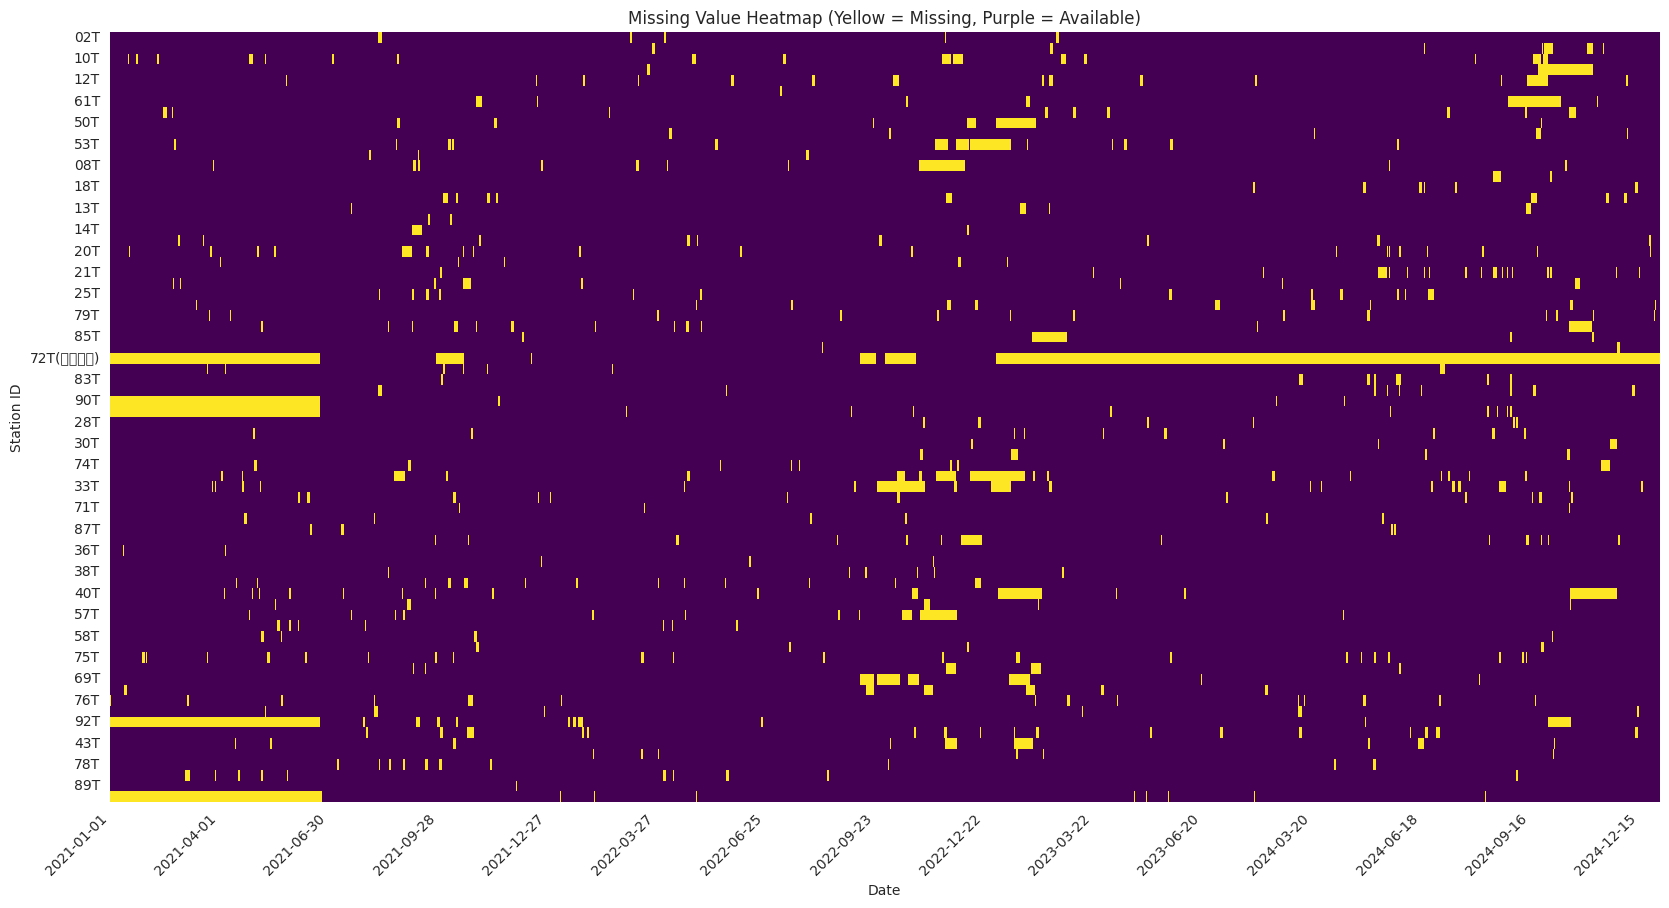

In [ ]:
plt.figure(figsize=(20, 10))
ax = sns.heatmap(df_legacy.isnull().T, cbar=False, cmap='viridis')
n_days = len(df_legacy)
xticks_interval = 90
xticks_locs = range(0, n_days, xticks_interval)
xtick_labels = [df_legacy.index[i].strftime('%Y-%m-%d') for i in xticks_locs if i < n_days]
plt.xticks(ticks=xticks_locs, labels=xtick_labels, rotation=45, ha='right')

plt.title('Missing Value Heatmap (Yellow = Missing, Purple = Available)')
plt.xlabel('Date')
plt.ylabel('Station ID')
plt.show()

เนื่องจากสถานี 72T(ใหม่) มีค่าหลุดหายเยอะมากเราจึง drop columns นี้ทิ้ง

In [ ]:
df_legacy = df_legacy.drop("72T(ใหม่)", axis=1)

ตรวจสอบค่าว่างที่เหลืออยู่

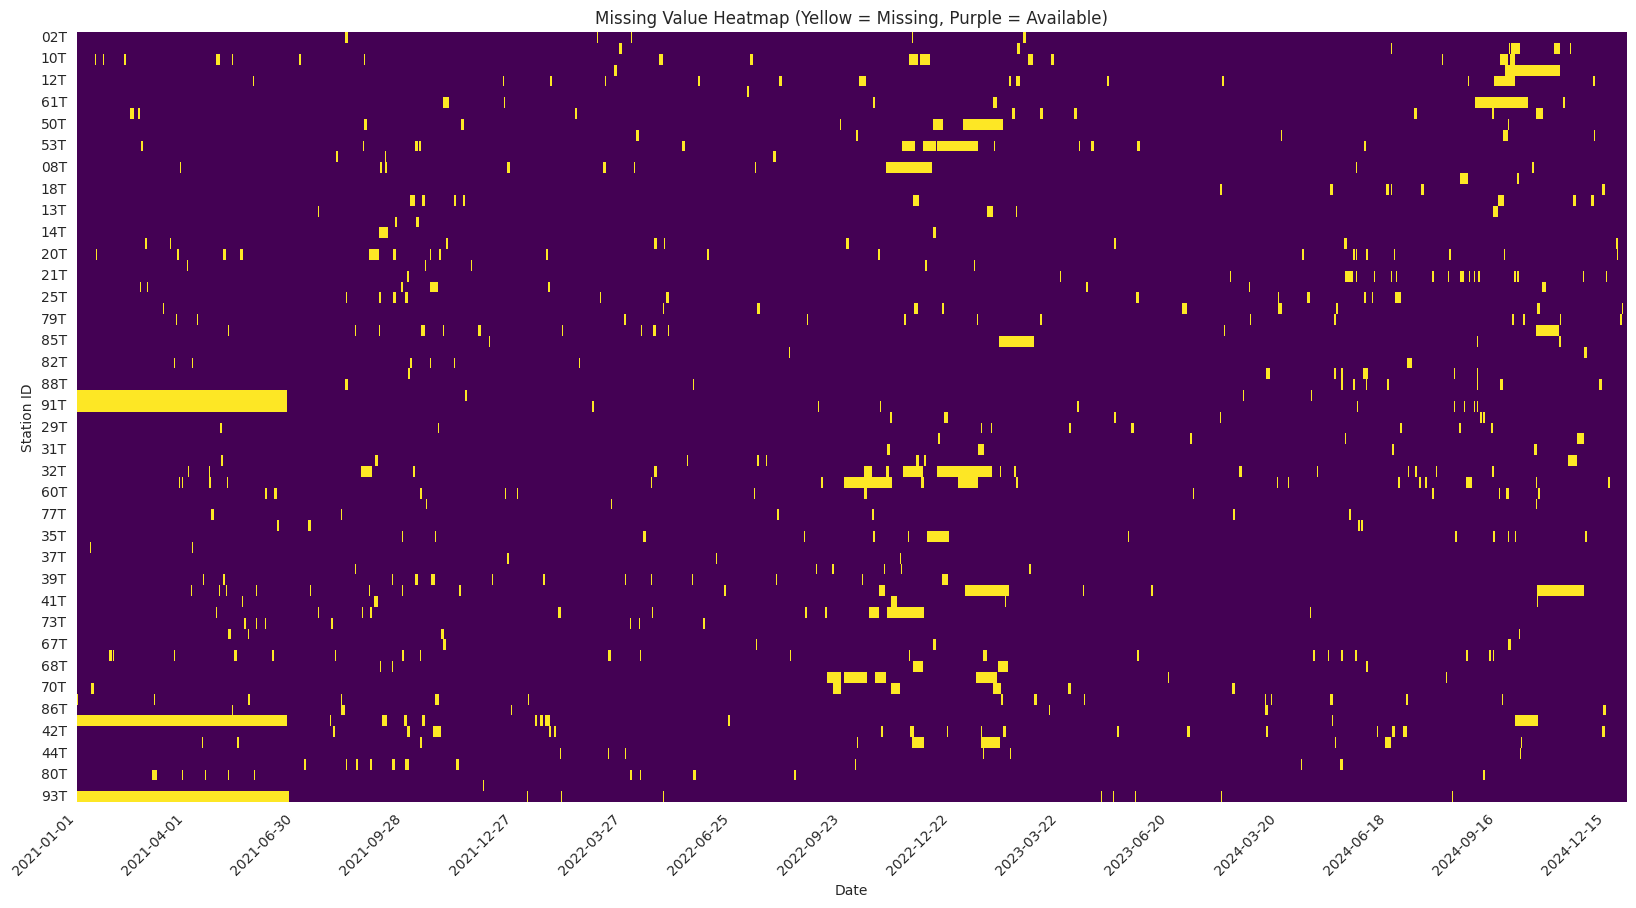

In [ ]:
plt.figure(figsize=(20, 10))
ax = sns.heatmap(df_legacy.isnull().T, cbar=False, cmap='viridis')
n_days = len(df_legacy)
xticks_interval = 90
xticks_locs = range(0, n_days, xticks_interval)
xtick_labels = [df_legacy.index[i].strftime('%Y-%m-%d') for i in xticks_locs if i < n_days]
plt.xticks(ticks=xticks_locs, labels=xtick_labels, rotation=45, ha='right')

plt.title('Missing Value Heatmap (Yellow = Missing, Purple = Available)')
plt.xlabel('Date')
plt.ylabel('Station ID')
plt.show()

* เนื่องจากมีประมาณ 4-5 สถานีที่เเม้ว่าจะเป็นการติดตั้งก่อนหน้าอีกกลุ่มนึงเเต่ยังมีข้อมูลที่หายไปครึ่งปี

* ความคิดเห็น: เราควรเก็บสถานีเหล่านี้ไว้ เพราะเราตัดสถานีออกเยอะมากถ้าเราตัดอันนี้มันอาจทำให้เกิดการ bias ได้model จะได้เรียนรู้เเต่สถานีที่perfect

* ดังนั้นทางออกคือ: เราจะตัดให้ dataframe เริ่มต้นที่กลางปี 2021 คือตอนที่ทุกสถานีในกลุ่มนี้เปิดใช้งานเเล้ว(เพราะถ้าคำนึงถึง พฤติกรรมของ sesonal ที่ต้องการ 4 ปี เรายังมีให้ได้ถึง 3.5ปี เเละข้อมูลไม่ bias)

In [ ]:
sync_start_date = '2021-07-01'

df_legacy_final = df_legacy.loc[sync_start_date:].copy()
df_legacy_final

,02T,05T,10T,11T,12T,59T,61T,03T,50T,52T,...,76T,86T,92T,42T,43T,44T,78T,80T,89T,93T
Date,,,,,,,,,,,,,,,,,,,,,
2021-07-01,10.0,8.0,7.0,10.0,11.0,8.0,13.0,20.0,13.0,13.0,...,6.0,6.0,8.0,13.0,15.0,17.0,10.0,10.0,16.0,13.0
2021-07-02,17.0,11.0,10.0,14.0,11.0,9.0,15.0,17.0,18.0,18.0,...,6.0,5.0,7.0,12.0,13.0,19.0,10.0,8.0,12.0,16.0
2021-07-03,9.0,8.0,NaN,9.0,8.0,7.0,13.0,18.0,12.0,12.0,...,5.0,5.0,11.0,12.0,11.0,17.0,10.0,8.0,17.0,14.0
2021-07-04,10.0,7.0,NaN,8.0,8.0,6.0,13.0,15.0,11.0,12.0,...,8.0,7.0,14.0,10.0,12.0,16.0,8.0,8.0,15.0,11.0
2021-07-05,9.0,7.0,8.0,8.0,8.0,7.0,14.0,15.0,13.0,11.0,...,8.0,9.0,14.0,8.0,12.0,15.0,9.0,9.0,12.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-27,47.4,35.4,35.8,35.4,35.9,23.2,34.6,43.9,41.6,46.2,...,34.6,52.6,25.9,12.1,12.4,12.0,12.3,12.3,12.4,12.2
2024-12-28,28.2,22.9,22.5,22.8,23.4,17.0,22.6,25.6,28.2,27.8,...,28.9,36.6,23.7,8.5,9.8,9.7,8.5,9.5,8.4,7.5
2024-12-29,25.8,20.1,20.4,20.6,20.7,17.0,20.1,22.3,23.8,25.2,...,21.7,24.7,20.9,8.8,10.1,10.1,8.7,10.1,7.7,7.9


ดูภาพรวมการกระจายตัวค่าว่างตอนนี้

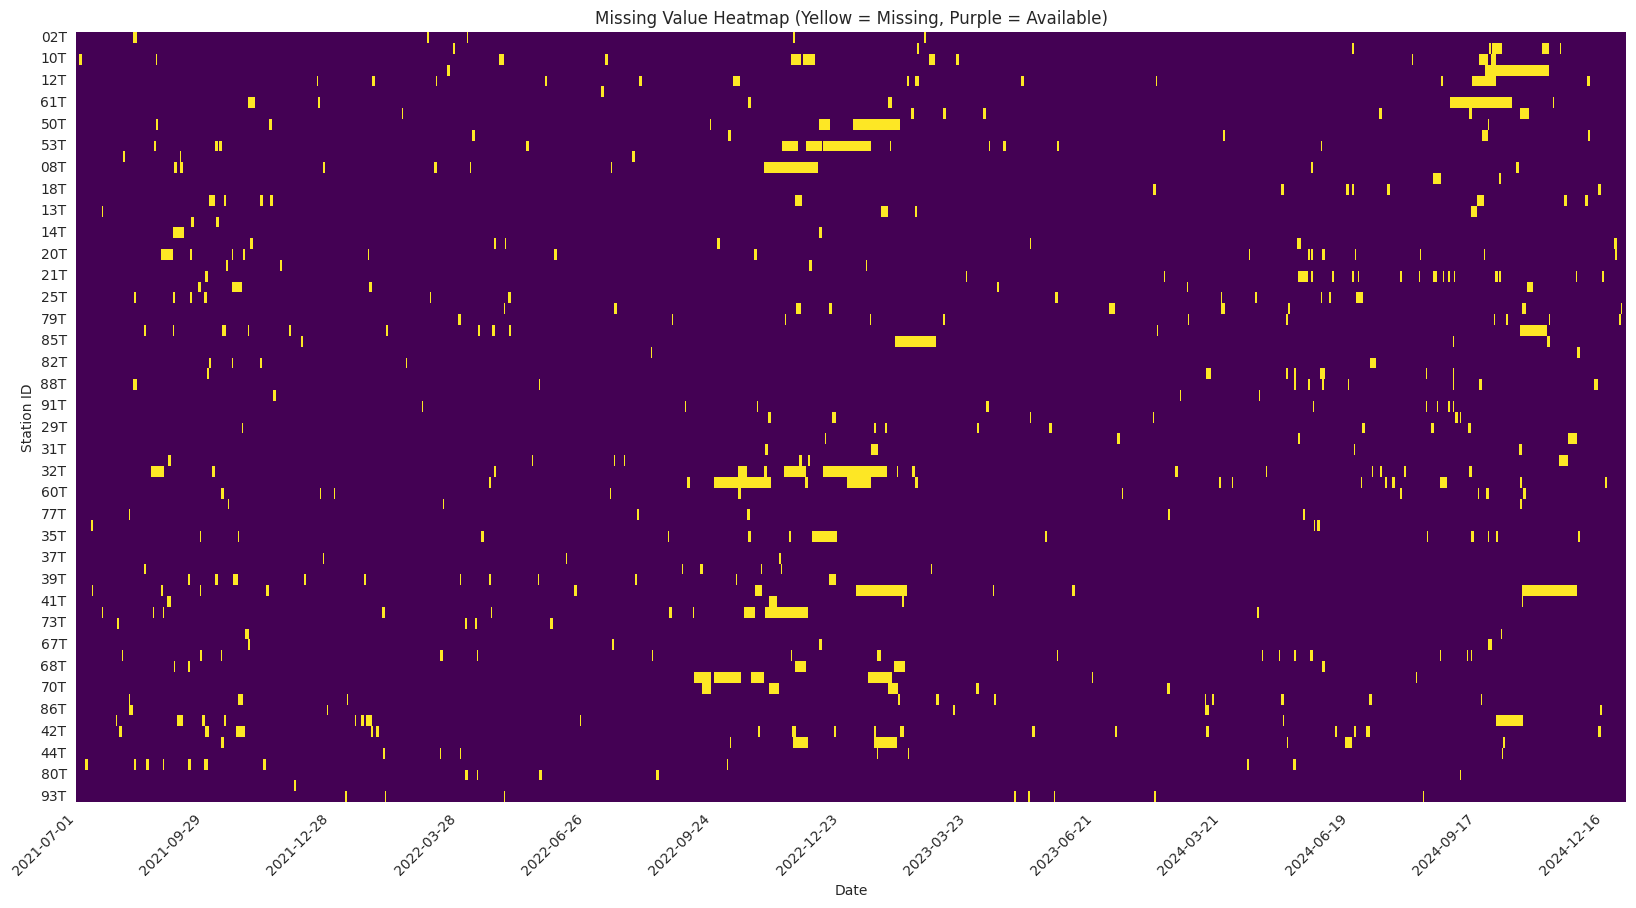

In [ ]:
plt.figure(figsize=(20, 10))
ax = sns.heatmap(df_legacy_final.isnull().T, cbar=False, cmap='viridis')
n_days = len(df_legacy_final)
xticks_interval = 90
xticks_locs = range(0, n_days, xticks_interval)
xtick_labels = [df_legacy_final.index[i].strftime('%Y-%m-%d') for i in xticks_locs if i < n_days]
plt.xticks(ticks=xticks_locs, labels=xtick_labels, rotation=45, ha='right')

plt.title('Missing Value Heatmap (Yellow = Missing, Purple = Available)')
plt.xlabel('Date')
plt.ylabel('Station ID')
plt.show()

จากกราฟจะเห็นว่าเราเหลือเเต่ข้อมูลที่หายเป็นช่วง ๆ

##### การจัดการข้อมูลเป็นช่วงสั้น ๆ ด้วยการเติมเเบบ interpolate

In [ ]:
df_final_legacy = df_legacy_final.copy()
df_final_legacy .interpolate(method='linear', limit_direction='both', inplace=True)

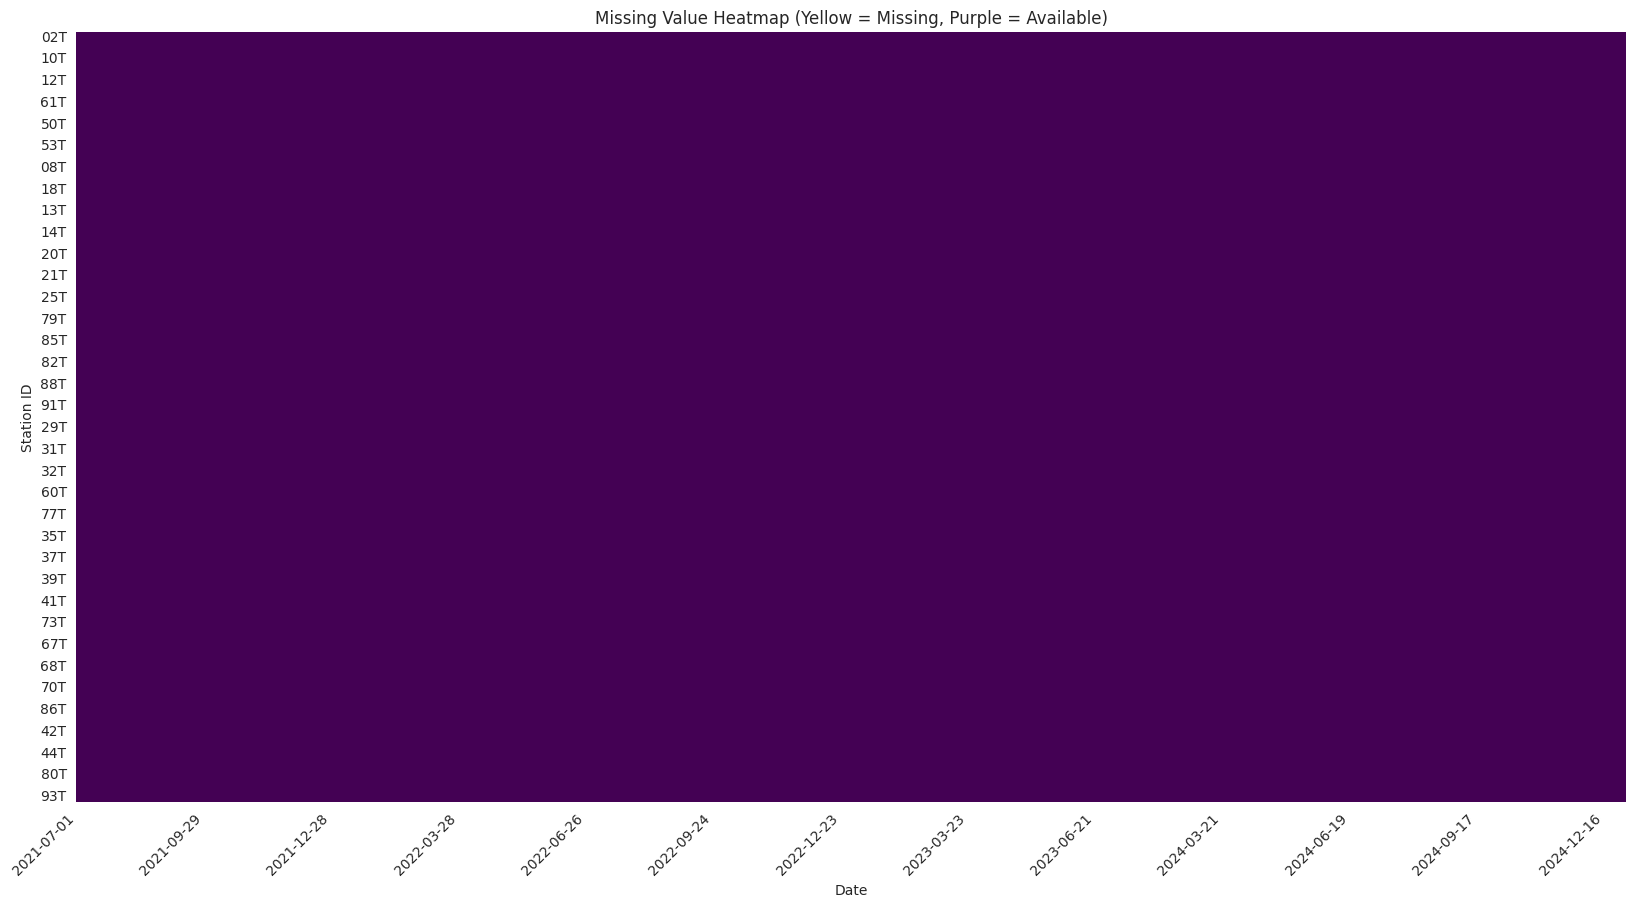

In [ ]:
plt.figure(figsize=(20, 10))
ax = sns.heatmap(df_final_legacy.isnull().T, cbar=False, cmap='viridis')

n_days = len(df_final_legacy)
xticks_interval = 90
xticks_locs = range(0, n_days, xticks_interval)
xtick_labels = [df_final_legacy.index[i].strftime('%Y-%m-%d') for i in xticks_locs if i < n_days]

plt.xticks(ticks=xticks_locs, labels=xtick_labels, rotation=45, ha='right')

plt.title('Missing Value Heatmap (Yellow = Missing, Purple = Available)')
plt.xlabel('Date')
plt.ylabel('Station ID')
plt.show()

ตอนนี้กลุ่มของสถานีที่ติดตั้งก่อนไม่มีค่าว่างเเล้ว

In [ ]:
df_final_legacy.to_csv("pm25_model_ready.csv")

####3.2 สถานีที่มีการติดตั้งทีหลัง

In [ ]:
df_new

,99T,103T,101T,102T,100T,94T,95T,96T,97T,98T,72T,104T,106T,107T,108T,109T,110T,111T,112T,105T
Date,,,,,,,,,,,,,,,,,,,,
2021-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-27,32.5,26.0,13.8,20.6,18.7,27.9,42.5,35.2,24.4,51.2,30.1,30.3,10.7,23.5,20.7,22.9,16.9,12.4,10.1,36.9
2024-12-28,23.0,24.7,9.5,17.7,14.4,27.3,35.0,28.3,21.0,37.8,18.2,24.4,10.1,20.4,19.3,22.7,17.4,9.7,9.8,14.4
2024-12-29,23.0,20.5,27.0,30.3,15.8,23.0,23.8,19.7,19.2,24.9,18.7,25.1,15.1,32.9,17.9,35.3,29.5,23.2,22.5,12.0


ดูการกระจายตัวของค่าว่าง

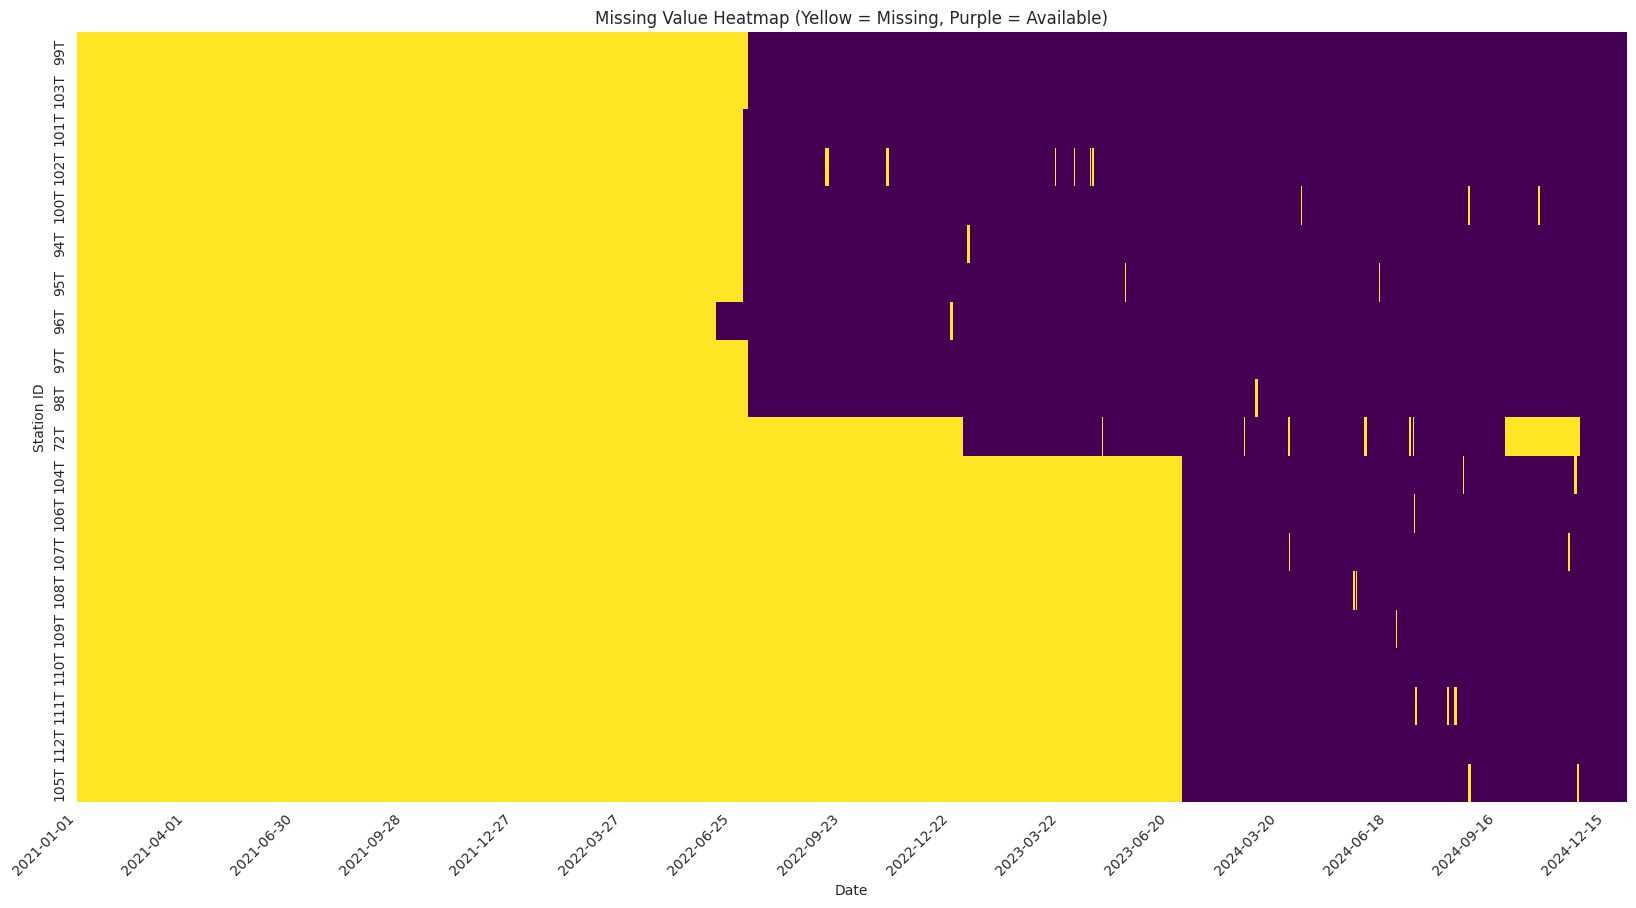

In [ ]:
plt.figure(figsize=(20, 10))
ax = sns.heatmap(df_new.isnull().T, cbar=False, cmap='viridis')
n_days = len(df_new)
xticks_interval = 90
xticks_locs = range(0, n_days, xticks_interval)
xtick_labels = [df_new.index[i].strftime('%Y-%m-%d') for i in xticks_locs if i < n_days]
plt.xticks(ticks=xticks_locs, labels=xtick_labels, rotation=45, ha='right')

plt.title('Missing Value Heatmap (Yellow = Missing, Purple = Available)')
plt.xlabel('Date')
plt.ylabel('Station ID')
plt.show()

ลบ 72T ออกเนื่องจาก สถานี 72T หลังจากที่มีการติดตั้งไปเเล้ว(เริ่มม่วง)ยังมีแถบสีเหลืองอยู่มาก ถ้าเติมจะเป็นการมั่วค่าตัวเลขขึ้นมา ซึ่งทำให้โมเดลไม่เเม่นยำ

In [ ]:
if '72T' in df_new.columns:
    df_new.drop(columns=['72T'], inplace=True)

- จากกราฟก็ยังเห็นได้ว่ากลุ่มของสถานีที่เกิดขึ้นทีหลังนั้นก็มีหลายช่วง ไม่สามารถเอามาเข้า model ร่วมกันได้ ดังนั้นเราจะเเบ่งเป็นอีกสองกลุ่มย่อยคือ กลุ่มที่เกิดก่อน 2022-07-03  เเละหลัง 2022-07-03
- เเล้วจะทำความสะอาดข้อมูลเพียงกลุ่มที่เกิดก่อน เนื่องจากข้อมูลที่เกิดหลังจากนั้นจะไปติดตั้งอีกทีช่วง 2023 เลยยังไม่สามารถเอามาคำนวนอะไรได้เนื่องจากมีข้อมูลไม่ถึง 1 ปี

In [ ]:
station_longevity = {}
for col in df_new.columns:
    if col != 'Date':
        first_idx = df_new[col].first_valid_index()
        if first_idx is not None:
            days_active = (df_new.index.max() - first_idx).days
            station_longevity[col] = days_active
longevity_series = pd.Series(station_longevity).sort_values(ascending=False)
valid_new_stations = longevity_series[longevity_series > 365].index.tolist()

เติมด้วย interpolate

In [ ]:
df_new_clean = df_new[valid_new_stations].copy()
df_new_clean.interpolate(method='linear', limit=5, limit_direction='both', inplace=True)

start_date_tier2 = '2022-07-03'
df_new_final = df_new_clean.loc[start_date_tier2:].copy()

In [ ]:
# กลุ่มย่อยที่พึ่งมาติดตั้งช่วงก่อน 2022-07-03
df_new_final

,96T,101T,102T,100T,94T,95T,99T,103T,98T,97T
Date,,,,,,,,,,
2022-07-03,6.0,6.0,7.0,4.0,7.0,7.0,8.0,6.0,10.0,8.0
2022-07-04,7.0,6.0,7.0,4.0,7.0,7.0,8.0,6.0,10.0,8.0
2022-07-05,6.0,5.0,6.0,4.0,5.0,9.0,8.0,6.0,10.0,8.0
2022-07-06,6.0,6.0,10.0,4.0,5.0,11.0,8.0,6.0,10.0,8.0
2022-07-07,5.0,8.0,8.0,8.0,6.0,11.0,8.0,6.0,10.0,8.0
...,...,...,...,...,...,...,...,...,...,...
2024-12-27,35.2,13.8,20.6,18.7,27.9,42.5,32.5,26.0,51.2,24.4
2024-12-28,28.3,9.5,17.7,14.4,27.3,35.0,23.0,24.7,37.8,21.0
2024-12-29,19.7,27.0,30.3,15.8,23.0,23.8,23.0,20.5,24.9,19.2


ดูการกระจายตัวข้อมูล

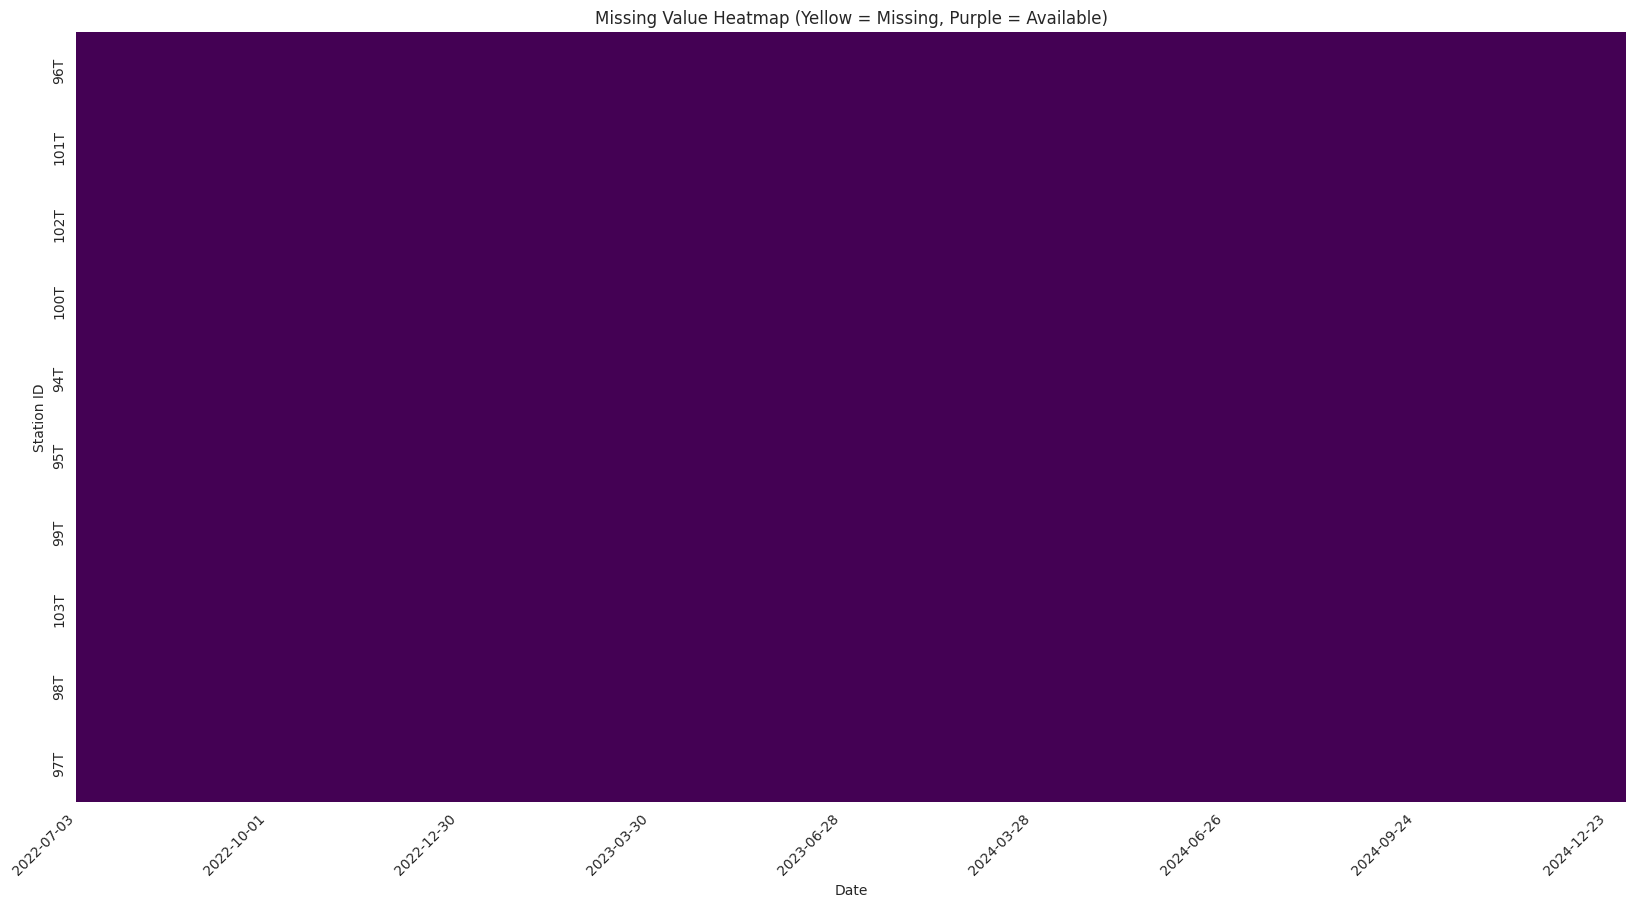

In [ ]:
plt.figure(figsize=(20, 10))
ax = sns.heatmap(df_new_final.isnull().T, cbar=False, cmap='viridis')
n_days = len(df_new_final)
xticks_interval = 90
xticks_locs = range(0, n_days, xticks_interval)
xtick_labels = [df_new_final.index[i].strftime('%Y-%m-%d') for i in xticks_locs if i < n_days]
plt.xticks(ticks=xticks_locs, labels=xtick_labels, rotation=45, ha='right')

plt.title('Missing Value Heatmap (Yellow = Missing, Purple = Available)')
plt.xlabel('Date')
plt.ylabel('Station ID')
plt.show()

### สรุป Data Preparation สำหรับ Missing Values

จากการตรวจสอบข้อมูล พบปัญหาคือความไม่ต่อเนื่องของข้อมูล ในรูปแบบขั้นบันไดจากการติดตั้งสถานีไม่พร้อมกัน

* พบประเด็นสำคัญดังนี้:
  1. สถานีที่มีสัดส่วนข้อมูลหาย สูงเกิน 20% และขาดการติดต่อต่อเนื่องนานเกิน 48 ชั่วโมง
  2. สถานีไม่ได้เริ่มเก็บข้อมูลพร้อมกันมีทั้งกลุ่มเก่า (2021) และกลุ่มใหม่ (2022-2024)
  3. สถานี 72T และ 72T(ใหม่) พบความผิดปกติของ Sensor อย่างรุนแรง (ข้อมูลหายเกือบ 100% ในบางช่วง)

* การจัดการ 4 ขั้นตอนหลักดังนี้:
  1. กรองเบื้องต้น
      - ลบสถานีที่มี Missing Ratio > 20% หรือ ขาดการติดต่อนานเกิน 48 ชม
        ข้อยกเว้นสถานีที่เพิ่งติดตั้ง
  2. การแบ่งกลุ่มข้อมูล
      - เพื่อแก้ปัญหาข้อมูลเริ่มไม่พร้อมกัน เราแบ่งสถานีออกเป็น 3 กลุ่ม:

        Tier 1: สถานีรุ่นเก่า (ติดตั้งก่อนกลางปี 2021) -> เก็บไว้ใช้งานหลัก

        Tier 2: สถานีรุ่นกลาง (ติดตั้งประมาณกลางปี 2022) -> เก็บไว้ใช้งานรอง

        Tier 3: สถานีรุ่นใหม่ (ติดตั้งปลายปี 2023-2024) -> ตัดออก (Excluded) เนื่องจากข้อมูลน้อยกว่า 1 ปี ไม่เพียงพอต่อการวิเคราะห์ Trend หรือ Seasonality

    3. การจัดการช่วงเวลาTrimming ส่วนหัว

    4. การเติมเต็มข้อมูล ใช้ Interpolation


##  Tranfrom data format

เนื่องจากเราจะนำข้อมูลเข้าไป train ใน pycacret เเต่ pycaret รองรับการใส่ traget เเค่ตัวเดียว ดังนั้นเราจึงทำการเปลี่ยนรูปเเบบข้อมูลจาก Wide format เป็น Long format เพื่อให้เราสามารถเทรน model โดยใช้ข้อมูลชุดเดียวกันที่เราเเบ่งมาได้

In [ ]:
df_prep = df_new_final.copy()
if df_prep.index.name != 'Date':
    df_prep.index.name = 'Date'

# ปรับรูปร่างข้อมูล (Wide -> Long) ให้มี Target เดียว
df_long = df_prep.reset_index().melt(
    id_vars='Date',
    var_name='Station_ID',
    value_name='PM25'
)

# เรียงข้อมูลตามสถานีและเวลา เพื่อให้เรียงลำดับอดีต-อนาคตถูกต้อง
df_long.sort_values(by=['Station_ID', 'Date'], inplace=True)
df_long.reset_index(drop=True, inplace=True)

In [ ]:
WINDOW_SIZE = 7
for i in range(1, WINDOW_SIZE + 1):
    df_long[f'PM25_lag_{i}'] = df_long.groupby('Station_ID')['PM25'].shift(i)
df_long.dropna(inplace=True)
df_long = pd.get_dummies(df_long, columns=['Station_ID'], drop_first=False)

## Train-Test-Split

นำข้อมูลของ Tire 1 เพื่อมาทำโมเดล regression เเต่เนื่องจากข้อมูลเป็นเเบบ Time-series ดังนั้นเราไม่สามารถสุ่มเเบ่งข้อมูลได้ เราจึงคำนวณตำแหน่ง 80% ของข้อมูลทั้งหมด แล้วหั่นแบ่งบน-ล่าง

In [ ]:
unique_dates = df_long['Date'].sort_values().unique()
split_idx = int(len(unique_dates) * 0.8) # แบ่งที่ 80% ของระยะเวลาทั้งหมด
split_date = unique_dates[split_idx]

train_df = df_long[df_long['Date'] < split_date].copy()
test_df = df_long[df_long['Date'] >= split_date].copy()

# ลบคอลัมน์ Date ออก เพราะรันเข้าสมการคณิตศาสตร์ตรงๆ ไม่ได้
train_df.drop(columns=['Date'], inplace=True)
test_df.drop(columns=['Date'], inplace=True)

## Data Scaling

การแปลงค่าของตัวแปรทั้งหมดให้อยู่ในช่วง 0 ถึง 1 (ปรับให้มีค่าเฉลี่ยเป็น 0 และส่วนเบี่ยงเบนมาตรฐานเป็น 1 ) เพื่อป้องกันไม่ให้ตัวแปรที่มีค่าตัวเลขสูง ๆ มีอิทธิพลกลบตัวแปรที่มีค่าตัวเลขต่ำ ๆ


เเละต้องต้องคำนวณสเกล (Fit) จากชุด Train เท่านั้น แล้วค่อยนำมาแปลง (Transform) ชุด Test เพื่อป้องกัน Data Leakage

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
scaler = MinMaxScaler()
feature_cols = [col for col in train_df.columns if col != 'PM25']

train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
test_df[feature_cols] = scaler.transform(test_df[feature_cols])

# Modeling

ทำการใช้ Pycaret ในกลุ่ม Regression Model เพื่อทำการ train เเละ test

ทำการ load pycaret

In [ ]:
!pip install git+https://github.com/pycaret/pycaret.git@master --upgrade

  Cloning https://github.com/pycaret/pycaret.git (to revision master) to /tmp/pip-req-build-21_fy5ez
  Running command git clone --filter=blob:none --quiet https://github.com/pycaret/pycaret.git /tmp/pip-req-build-21_fy5ez
  Resolved https://github.com/pycaret/pycaret.git to commit 58ec3c282d58e94727f9d5b77b49f241e9103ab3
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


นำเข้า pycaret regression เพื่อใช้ model ที่อยู่ในนั้น

In [ ]:
from pycaret.regression import *
reg_exp = setup(
    data=train_df,
    test_data=test_df,
    target="PM25",
    session_id=42,
    preprocess=False,
    fold=5,
    verbose=True
)

,Description,Value
0,Session id,42
1,Target,PM25
2,Target type,Regression
3,Original data shape,"(7220, 18)"
4,Transformed data shape,"(7220, 18)"
5,Transformed train set shape,"(5770, 18)"
6,Transformed test set shape,"(1450, 18)"
7,Numeric features,17


In [ ]:
best_reg = compare_models()
best_reg

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
br,Bayesian Ridge,4.9473,58.4032,7.5726,0.8374,0.2521,0.2243,0.0720
huber,Huber Regressor,4.8872,58.5901,7.5868,0.8366,0.2473,0.2100,0.2220
ridge,Ridge Regression,5.0363,59.5650,7.6381,0.8352,0.2557,0.2320,0.0300
par,Passive Aggressive Regressor,5.0715,61.2880,7.7585,0.8286,0.2601,0.2237,0.0920
omp,Orthogonal Matching Pursuit,5.0689,61.6613,7.7803,0.8280,0.2609,0.2351,0.0700
gbr,Gradient Boosting Regressor,5.0447,64.6354,7.9006,0.8271,0.2524,0.2231,0.6760
et,Extra Trees Regressor,5.1195,70.0843,8.1492,0.8198,0.2541,0.2220,1.8340
rf,Random Forest Regressor,5.1568,69.6853,8.1490,0.8183,0.2561,0.2247,3.6220
lightgbm,Light Gradient Boosting Machine,5.2129,75.5258,8.4283,0.8090,0.2545,0.2226,0.4500
xgboost,Extreme Gradient Boosting,5.4343,78.6369,8.6629,0.7949,0.2652,0.2315,0.1780


Processing:   0%|          | 0/81 [00:00<?, ?it/s]

BayesianRidge()

# Evaluation

model ที่ดีที่สุดคือ Bayesian Ridge เนื่องจากมีค่า error น้อยที่สุดในทุกตัว รวมทั้งมีค่า r square สูงสุด

In [ ]:
br_reg = create_model("br")
tuned_br_reg = tune_model(br_reg)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,4.1149,36.5458,6.0453,0.7868,0.2903,0.2793
1,4.7626,53.2018,7.2940,0.8093,0.2493,0.2097
2,4.9381,57.5893,7.5888,0.8730,0.2493,0.2207
3,5.6261,85.8955,9.2680,0.8875,0.2371,0.2073
4,5.2947,58.7834,7.6670,0.8307,0.2344,0.2042
Mean,4.9473,58.4032,7.5726,0.8374,0.2521,0.2243
Std,0.5116,15.8835,1.0290,0.0379,0.0201,0.0281


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,4.1147,36.5444,6.0452,0.7868,0.2903,0.2793
1,4.7626,53.1950,7.2935,0.8093,0.2493,0.2098
2,4.9386,57.5896,7.5888,0.8730,0.2494,0.2208
3,5.6260,85.8991,9.2682,0.8875,0.2371,0.2072
4,5.2947,58.7834,7.6670,0.8307,0.2344,0.2042
Mean,4.9473,58.4023,7.5725,0.8375,0.2521,0.2243
Std,0.5116,15.8856,1.0291,0.0378,0.0201,0.0281


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 5 folds for each of 10 candidates, totalling 50 fits


In [ ]:
final_reg = finalize_model(tuned_br_reg)

pred_reg = predict_model(final_reg, data=test_df.sample(10, random_state=1))
pred_reg

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Bayesian Ridge,3.4619,18.5901,4.3116,0.8175,0.1959,0.1779


,PM25_lag_1,PM25_lag_2,PM25_lag_3,PM25_lag_4,PM25_lag_5,PM25_lag_6,PM25_lag_7,Station_ID_100T,Station_ID_101T,Station_ID_102T,Station_ID_103T,Station_ID_94T,Station_ID_95T,Station_ID_96T,Station_ID_97T,Station_ID_98T,Station_ID_99T,PM25,prediction_label
6456,0.077434,0.075221,0.062832,0.054425,0.049558,0.046903,0.041593,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,16.600000,18.900700
2865,0.087611,0.086283,0.077434,0.072566,0.045575,0.068142,0.084513,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,25.799999,21.296255
5761,0.032301,0.035398,0.033186,0.040708,0.040265,0.072124,0.076549,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,9.700000,11.122102
3509,0.023894,0.016814,0.023894,0.022566,0.037611,0.038053,0.021239,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,6.600000,8.680849
621,0.011947,0.030973,0.026106,0.026991,0.047788,0.037168,0.043805,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.700000,5.683322
3644,0.120796,0.092920,0.111947,0.114602,0.110177,0.135398,0.132301,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,32.000000,30.249804
6524,0.110177,0.152212,0.141593,0.123451,0.111947,0.113274,0.103540,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,31.799999,26.153326
675,0.026106,0.026106,0.032301,0.090708,0.092478,0.083186,0.105752,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.900000,10.806076
5777,0.058407,0.054425,0.120354,0.129204,0.092035,0.053540,0.044690,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,26.600000,17.299549
7239,0.161504,0.126991,0.107965,0.111947,0.061504,0.065929,0.119027,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,30.900000,36.404129


1. MAE (Mean Absolute Error): 3.4619
โดยเฉลี่ยแล้ว model ทายผิดพลาดไปจากค่าจริงประมาณ 3.46 หน่วย

2. MSE (Mean Squared Error): 18.5901 เเละ RMSE (Root Mean Squared Error): 4.3116
ที่ไม่ได้สูงมากเเปลว่าโมเดลค่อนข้างเเม่นยำ


3. R2 (R-Squared): 0.8175
 หมายความว่า โมเดลของสามารถอธิบายข้อมูลได้ถูกต้องประมาณ 81.75% ซึ่งถือว่าอยู่ในเกณฑ์ดี


สรุปภาพรวม
โมเดลของคุณมีประสิทธิภาพ อยู่ในเกณฑ์ดีเพราะ:

R2 สูงถึง 0.81 แสดงว่าโมเดลเรียนรู้แพทเทิร์นของข้อมูลได้เก่ง

In [ ]:
evaluate_model(final_reg)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

# Deployment

In [ ]:
!pip install gradio

In [ ]:
import gradio as gr
import pandas as pd
import numpy as np

def smart_predict(station_id, *lags):
    try:
        if station_id is None:
            return "<div style='color:red;'>กรุณาเลือกสถานี</div>"

        if any(v is None for v in lags):
            latest_values = df_final_legacy[station_id].tail(7).values
        else:
            latest_values = np.array(lags)[::-1]

        data = {f'PM25_lag_{i}': [latest_values[-i]] for i in range(1, 8)}
        input_df = pd.DataFrame(data)

        all_station_cols = [col for col in train_df.columns if 'Station_ID_' in col]
        for col in all_station_cols:
            input_df[col] = 1 if col == f'Station_ID_{station_id}' else 0

        input_df[feature_cols] = scaler.transform(input_df[feature_cols])

        prediction = predict_model(final_reg, data=input_df)['prediction_label'][0]

        if prediction <= 15.0:
            color, bg, status, advice = "#00E400", "#e6f9e6", "ดีมาก", "อากาศสดชื่น เหมาะแก่การทำกิจกรรมกลางแจ้งทุกประเภท"
        elif prediction <= 25.0:
            color, bg, status, advice = "#FFFF00", "#ffffeb", "ดี", "ทำกิจกรรมกลางแจ้งได้ตามปกติ ผู้ที่แพ้ง่ายควรสังเกตอาการ"
        elif prediction <= 37.5:
            color, bg, status, advice = "#FF7E00", "#fff3e6", "ปานกลาง", "ควรลดระยะเวลาการทำกิจกรรมกลางแจ้งที่ใช้แรงมาก"
        elif prediction <= 75.0:
            color, bg, status, advice = "#FF0000", "#ffe6e6", "เริ่มมีผลกระทบ", "ควรสวมหน้ากากอนามัยเมื่อออกนอกบ้าน และลดกิจกรรมกลางแจ้ง"
        else:
            color, bg, status, advice = "#7E0023", "#f2e6e9", "มีผลกระทบมาก", "อันตราย! งดกิจกรรมกลางแจ้ง อยู่ในอาคารและเปิดเครื่องฟอกอากาศ"

        return f"""
        <div style="text-align: center; padding: 25px; background-color: white; border-radius: 15px; border-top: 10px solid {color}; box-shadow: 0 10px 25px rgba(0,0,0,0.1); font-family: 'Prompt', sans-serif;">
            <div style="margin-bottom: 10px;">
                <span style="font-size: 18px; color: #888;">📍 สถานี {station_id}</span>
            </div>
            <div style="margin-bottom: 5px;">
                <span style="font-size: 64px; font-weight: 800; color: #333;">{prediction:.1f}</span>
                <span style="font-size: 20px; color: #999; margin-left: 5px;">µg/m³</span>
            </div>
            <div style="display: inline-block; padding: 6px 20px; border-radius: 50px; background-color: {color}; color: {'#333' if status=='ดี' else 'white'}; font-weight: bold; font-size: 18px; margin-bottom: 20px;">
                {status}
            </div>
            <div style="text-align: left; background-color: #f8f9fa; padding: 15px; border-radius: 12px; border-left: 4px solid {color};">
                <p style="margin: 0; font-size: 14px; color: #666; font-weight: bold;">🛡️ คำแนะนำสำหรับพรุ่งนี้:</p>
                <p style="margin: 5px 0 0 0; font-size: 16px; color: #444; line-height: 1.4;">{advice}</p>
            </div>
        </div>
        """
    except Exception as e:
        return f"<div style='color: red; padding: 20px; text-align: center;'>⚠️ <b>ระบบขัดข้อง:</b> {str(e)}</div>"


actual_stations = df_final_legacy.columns.tolist()

with gr.Blocks(css=".compact-btn { height: 45px !important; font-size: 16px !important; margin-top: 5px !important; border-radius: 10px !important; } .custom-dropdown { margin-bottom: 0px !important; }") as demo:
    gr.Markdown("# 🌬️ ระบบพยากรณ์และเฝ้าระวังฝุ่น PM2.5 อัจฉริยะ")

    with gr.Row():
        with gr.Column(scale=1):
            station_dropdown = gr.Dropdown(choices=actual_stations, label="🔍 ค้นหาสถานีใกล้คุณ", elem_classes="custom-dropdown")

            lag_inputs = [gr.Number(label=f"ย้อนหลัง {i} วัน") for i in range(7, 0, -1)]

            predict_btn = gr.Button("🚀 วิเคราะห์ผลวันพรุ่งนี้", variant="primary", elem_classes="compact-btn")

            gr.Markdown('<div style="font-size: 13px; color: #888; margin-top: 15px;"><b>เกณฑ์ระดับสี:</b> 🔵 ดีมาก | 🟢 ดี | 🟡 ปานกลาง | 🟠 เริ่มกระทบ | 🔴 กระทบมาก</div>')

        with gr.Column(scale=2):
            output_display = gr.HTML()

    predict_btn.click(fn=smart_predict, inputs=[station_dropdown] + lag_inputs, outputs=output_display)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d579dc121f4dbc9aaa.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import gradio as gr
import pandas as pd
import numpy as np

def smart_predict(station_id):
    try:
        latest_values = df_final_legacy[station_id].tail(7).values

        data = {f'PM25_lag_{i}': [latest_values[-i]] for i in range(1, 8)}
        input_df = pd.DataFrame(data)

        all_station_cols = [col for col in train_df.columns if 'Station_ID_' in col]
        for col in all_station_cols:
            input_df[col] = 1 if col == f'Station_ID_{station_id}' else 0

        input_df[feature_cols] = scaler.transform(input_df[feature_cols])

        prediction = predict_model(final_reg, data=input_df)['prediction_label'][0]

        # 🔥 เพิ่ม: ค่าจริงล่าสุด
        current_pm25 = latest_values[-1]
        diff = prediction - current_pm25
        trend = "📈 เพิ่มขึ้น" if diff > 0 else "📉 ลดลง"

        if prediction <= 15.0:
            color, bg, status, advice = "#00E400", "#e6f9e6", "ดีมาก", "อากาศสดชื่น เหมาะแก่การทำกิจกรรมกลางแจ้งทุกประเภท"
        elif prediction <= 25.0:
            color, bg, status, advice = "#FFFF00", "#ffffeb", "ดี", "ทำกิจกรรมกลางแจ้งได้ตามปกติ ผู้ที่แพ้ง่ายควรสังเกตอาการ"
        elif prediction <= 37.5:
            color, bg, status, advice = "#FF7E00", "#fff3e6", "ปานกลาง", "ควรลดระยะเวลาการทำกิจกรรมกลางแจ้งที่ใช้แรงมาก"
        elif prediction <= 75.0:
            color, bg, status, advice = "#FF0000", "#ffe6e6", "เริ่มมีผลกระทบ", "ควรสวมหน้ากากอนามัยเมื่อออกนอกบ้าน และลดกิจกรรมกลางแจ้ง"
        else:
            color, bg, status, advice = "#7E0023", "#f2e6e9", "มีผลกระทบมาก", "อันตราย! งดกิจกรรมกลางแจ้ง อยู่ในอาคารและเปิดเครื่องฟอกอากาศ"

        return f"""
        <div style="text-align: center; padding: 25px; background-color: white; border-radius: 15px;
                    border-top: 10px solid {color}; box-shadow: 0 10px 25px rgba(0,0,0,0.1);
                    font-family: 'Prompt', sans-serif;">

            <div style="margin-bottom: 10px;">
                <span style="font-size: 18px; color: #888;">📍 สถานี {station_id}</span>
            </div>

            <div style="margin-bottom: 5px;">
                <span style="font-size: 64px; font-weight: 800; color: #333;">{prediction:.1f}</span>
                <span style="font-size: 20px; color: #999;">µg/m³</span>
            </div>

            <div style="margin-bottom: 10px; font-size: 14px; color:#666;">
                วันนี้: {current_pm25:.1f} → พรุ่งนี้: {prediction:.1f} ({trend})
            </div>

            <div style="display: inline-block; padding: 6px 20px; border-radius: 50px;
                        background-color: {color}; color: {'#333' if status=='ดี' else 'white'};
                        font-weight: bold; font-size: 18px; margin-bottom: 20px;">
                {status}
            </div>

            <div style="text-align: left; background-color: #f8f9fa; padding: 15px;
                        border-radius: 12px; border-left: 4px solid {color};">
                <p style="margin: 0; font-size: 14px; color: #666; font-weight: bold;">
                    🛡️ คำแนะนำสำหรับพรุ่งนี้:
                </p>
                <p style="margin: 5px 0 0 0; font-size: 16px; color: #444;">
                    {advice}
                </p>
            </div>
        </div>
        """

    except Exception as e:
        return f"<div style='color: red; padding: 20px; text-align: center;'>⚠️ <b>ระบบขัดข้อง:</b> {str(e)}</div>"


actual_stations = df_final_legacy.columns.tolist()

with gr.Blocks(css="""
.compact-btn { height: 45px !important; font-size: 16px !important; margin-top: 5px !important; border-radius: 10px !important; }
.custom-dropdown { margin-bottom: 0px !important; }
""") as demo:

    gr.Markdown("# 🌬️ ระบบพยากรณ์และเฝ้าระวังฝุ่น PM2.5 อัจฉริยะ")

    with gr.Row():
        with gr.Column(scale=1):
            station_dropdown = gr.Dropdown(
                choices=actual_stations,
                label="🔍 ค้นหาสถานีใกล้คุณ",
                elem_classes="custom-dropdown"
            )

            predict_btn = gr.Button(
                "🚀 วิเคราะห์ผลวันพรุ่งนี้",
                variant="primary",
                elem_classes="compact-btn"
            )

            gr.Markdown("""
            <div style="font-size: 13px; color: #888; margin-top: 15px;">
            <b>เกณฑ์ระดับสี:</b> 🔵 ดีมาก | 🟢 ดี | 🟡 ปานกลาง | 🟠 เริ่มกระทบ | 🔴 กระทบมาก
            </div>
            """)

        with gr.Column(scale=2):
            output_display = gr.HTML()

    predict_btn.click(
        fn=smart_predict,
        inputs=station_dropdown,
        outputs=output_display
    )

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c3aae168a97ebd2303.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


เพื่อให้โครงการสามารถบรรลุเป้าหมายในการสร้างระบบช่วยตัดสินใจด้านการแจ้งเตือนสุขภาพ เราได้นำโมเดล Bayesian Ridge ที่ผ่านการปรับแต่งและทดสอบจนพร้อมใช้งาน (Finalize) มาพัฒนาเป็นหน้าตาโปรแกรม (User Interface) ผ่าน Gradio เพื่อให้ผู้ใช้งานสามารถเข้าถึงและใช้งานได้ง่าย

ในด้านการทำงานของระบบ มีรายละเอียดสำคัญดังนี้

**Data Pipeline Integration:**
ระบบถูกออกแบบให้สามารถดึงข้อมูลมาใช้งานได้แบบอัตโนมัติจากชุดข้อมูลหลักที่ผ่านการเตรียมไว้แล้ว โดยข้อมูลดังกล่าวได้ผ่านกระบวนการทำความสะอาด (Data Cleaning) และการจัดการค่าที่หายไปอย่างเหมาะสม ทำให้มั่นใจได้ว่าข้อมูลที่นำมาใช้มีคุณภาพ พร้อมสำหรับการวิเคราะห์และพยากรณ์

**Time-Series Feature Engineering:**
ในการพยากรณ์แต่ละครั้ง ระบบจะนำค่าฝุ่นย้อนหลัง 7 วันมาใช้สร้างตัวแปรที่เรียกว่า Lag Features (Lag 1 ถึง Lag 7) เพื่อสะท้อนแนวโน้มของข้อมูลในอดีต วิธีนี้ช่วยให้โมเดลเข้าใจรูปแบบการเปลี่ยนแปลงของค่าฝุ่นได้ดีขึ้น และเพิ่มความแม่นยำของผลลัพธ์

**Automatic Scaling & Transformation:**
ก่อนนำข้อมูลเข้าสู่โมเดล ระบบจะทำการปรับสเกลข้อมูลให้อยู่ในช่วง 0–1 โดยใช้ MinMaxScaler ที่เรียนรู้จากชุดข้อมูลฝึกสอนเท่านั้น ขั้นตอนนี้ช่วยลดผลกระทบจากความแตกต่างของช่วงตัวเลข และทำให้โมเดลทำงานได้อย่างมีประสิทธิภาพมากขึ้น

**Health Impact Mapping:**
ผลลัพธ์ที่ได้จากโมเดลซึ่งเป็นค่าฝุ่นในรูปแบบตัวเลข จะถูกแปลงให้เป็นคำแนะนำด้านสุขภาพที่เข้าใจง่าย โดยอิงตามมาตรฐานสากล (เช่น ระดับสีของคุณภาพอากาศ) เพื่อช่วยให้ผู้ใช้งานสามารถประเมินความเสี่ยง และวางแผนการป้องกันสุขภาพได้อย่างเหมาะสม

# ข้อเสนอเเนะ


1. หากต้องการให้แม่นขึ้น ลองเช็กดูว่าในข้อมูลมี Outliers (ค่าที่โดดผิดปกติ) หรือไม่ เพราะค่า MSE และ RMSE ค่อนข้างห่างจาก MAE พอสมควรครับ

2. เพื่อให้ข้อมูลของเราสามารถทำนายค่าฝุ่นในวันพรุ่งนี้ได้ต้องไปดึงข้อมูลจาก API ของกรมควบคุมมลพิษ หรือแหล่งข้อมูล Real-time มาใส่ใน df ก่อนจะรัน Gradio เพื่อหน้าเว็บจะอัปเดตตัวเองทุกวันตามเวลาจริง ไม่ต้องให้ user กรอกข

# บทสรุปและผลการดำเนินงาน

1. ประสิทธิภาพของโมเดล:
จากการทดลองเปรียบเทียบโมเดลหลายรูปแบบ พบว่าโมเดล Bayesian Ridge ให้ผลลัพธ์ดีที่สุด โดยมีค่าความคลาดเคลื่อนเฉลี่ย (MAE) เพียง 4.94 µg/m³ และค่า R-Squared สูงถึง 0.83 แสดงให้เห็นว่าโมเดลสามารถทำนายค่าได้ใกล้เคียงความจริงในระดับที่น่าเชื่อถือ เหมาะสำหรับการใช้งานกับข้อมูลลักษณะ Time-series

2. การจัดการข้อมูล (Data Quality):
โปรเจกต์นี้ให้ความสำคัญกับคุณภาพข้อมูลเป็นอย่างมาก โดยมีการจัดกลุ่มสถานีตรวจวัดออกเป็นระดับ (Tier) ตามความสมบูรณ์ของข้อมูลจากเซนเซอร์ และคัดกรองสถานีที่มีข้อมูลสูญหายเกินเกณฑ์ เช่น 72T หรือ 34T ออกไป เพื่อลดสัญญาณรบกวน (Noise) และช่วยให้โมเดลเรียนรู้จากข้อมูลที่มีคุณภาพมากขึ้น

3. ผลลัพธ์เชิงธุรกิจและการใช้งานจริง:
ระบบพยากรณ์ล่วงหน้า 1 วันที่พัฒนาขึ้น สามารถตอบโจทย์การเป็นเครื่องมือแจ้งเตือนด้านสุขภาพได้อย่างมีประสิทธิภาพ ช่วยให้ประชาชนสามารถเตรียมตัวรับมือกับสถานการณ์มลพิษทางอากาศล่วงหน้าได้ ขณะเดียวกันก็เป็นประโยชน์ต่อหน่วยงานหรือผู้กำหนดนโยบายในการวางแผนและตัดสินใจได้อย่างเหมาะสม

#จัดทำโดย:
1. 67070095 นางสาวบุษยมาศ สนบ้านเกาะ
2. 67070131 นางสาวภารดี พิมลเอกอักษร
3. 67070147 นางสาวยานวี ดูเบย์
4. 67070158 นางสาววราภรณ์ สร้างคำ
5. 67070178 นางสาวศุภิสรา หลายชั้น